## 1. Carga y verificación de la base limpia

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv to Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv",
    sep="\t"
)

df.head(100)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto
0,C000728,Cliente 0728,Mass,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NaN,0.00,Branch,Activo
1,C001264,Cliente 1264,Mass,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NaN,0.00,App,Activo
2,C001515,Cliente 1515,Joven,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,Food,16.63,Branch,Activo
3,C002171,Cliente 2171,Mass,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NaN,0.00,App,Activo
4,C001848,Cliente 1848,Premium,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,Food,51.91,App,Activo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,C000594,Cliente 0594,Mass,Guayaquil,49,973.26,Tarjeta de Crédito,284.24,2500.0,2030-07-07,2025-09-30,Travel,180.24,POS,Activo
96,C002138,Cliente 2138,Mass,Quito,25,1093.98,Tarjeta de Crédito,1061.19,2200.0,2029-07-10,2025-03-01,Entertainment,36.74,Branch,Activo
97,C000169,Cliente 0169,PyME,Quito,23,4894.01,Crédito Hipotecario,90392.84,NaN,2028-12-29,2026-05-07,NaN,0.00,Web,Activo
98,C000620,Cliente 0620,Premium,Quito,48,5739.22,Tarjeta de Crédito,4651.91,8700.0,2026-09-25,2025-09-24,Technology,930.75,App,Activo


In [5]:
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Filas y columnas: (22455, 15)

Columnas:
['cliente_id', 'nombre_cliente', 'segmento_cliente', 'ciudad', 'edad', 'ingreso_estimado', 'producto', 'saldo_producto', 'cupo_credito', 'fecha_vencimiento', 'fecha_movimiento', 'categoria_consumo', 'monto_consumo', 'canal', 'estado_producto']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22455 entries, 0 to 22454
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cliente_id         22455 non-null  object 
 1   nombre_cliente     22455 non-null  object 
 2   segmento_cliente   22455 non-null  object 
 3   ciudad             22277 non-null  object 
 4   edad               22455 non-null  int64  
 5   ingreso_estimado   22455 non-null  float64
 6   producto           22455 non-null  object 
 7   saldo_producto     22319 non-null  float64
 8   cupo_credito       14942 non-null  float64
 9   fecha_vencimiento  18991 non-null  object 
 10  fecha_movimiento   22455 non-null  object 
 11  categoria_consumo  14942 non-null  object 
 12  monto_consumo      22455 non-null  float64
 13  canal              22455 non-null  object 
 14  estado_producto    22455 non-null  object 
dtypes: float64(4), int64(1), object(10)
memory usage: 2.6+ MB


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})

nulos = nulos.sort_values("Porcentaje", ascending=False)

nulos

,Nulos,Porcentaje
cupo_credito,7513,33.458027
categoria_consumo,7513,33.458027
fecha_vencimiento,3464,15.426408
ciudad,178,0.792697
saldo_producto,136,0.605656
nombre_cliente,0,0.000000
cliente_id,0,0.000000
producto,0,0.000000
ingreso_estimado,0,0.000000
edad,0,0.000000


In [11]:
print("Duplicados completos:", df.duplicated().sum())

Duplicados completos: 113


In [12]:
print("Clientes únicos:", df["cliente_id"].nunique())
print("Registros:", len(df))

Clientes únicos: 2200
Registros: 22455


In [13]:
duplicados_cliente = (
    df["cliente_id"]
    .value_counts()
    .reset_index()
)

duplicados_cliente.columns = ["cliente_id", "cantidad_registros"]

duplicados_cliente.head(20)

,cliente_id,cantidad_registros
0,C001320,25
1,C002047,24
2,C000925,23
3,C000981,23
4,C001135,23
5,C001567,23
6,C001342,23
7,C000484,22
8,C001170,22
9,C000168,22


In [14]:
df["edad"].describe()

,edad
count,22455.000000
mean,38.738187
std,11.384750
min,18.000000
25%,31.000000
50%,39.000000
75%,47.000000
max,78.000000


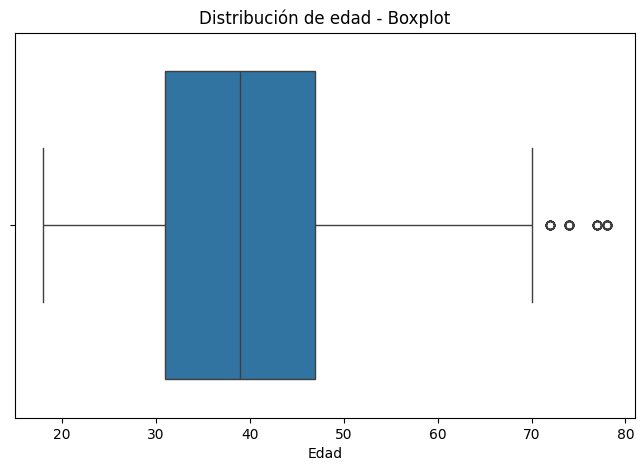

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["edad"].dropna())

plt.xlabel("Edad")
plt.title("Distribución de edad - Boxplot")
plt.show()

In [16]:
df["segmento_cliente"].value_counts()

,count
segmento_cliente,
Mass,9962
Affluent,4392
Premium,3059
Joven,2734
PyME,2037
pyme,58
Affluent,58
mass,56
JOVEN,54


In [17]:
df["segmento_cliente"] = (
    df["segmento_cliente"]
    .str.strip()
    .str.upper()
)

In [18]:
df["segmento_cliente"].value_counts()

,count
segmento_cliente,
MASS,10018
AFFLUENT,4450
PREMIUM,3104
JOVEN,2788
PYME,2095


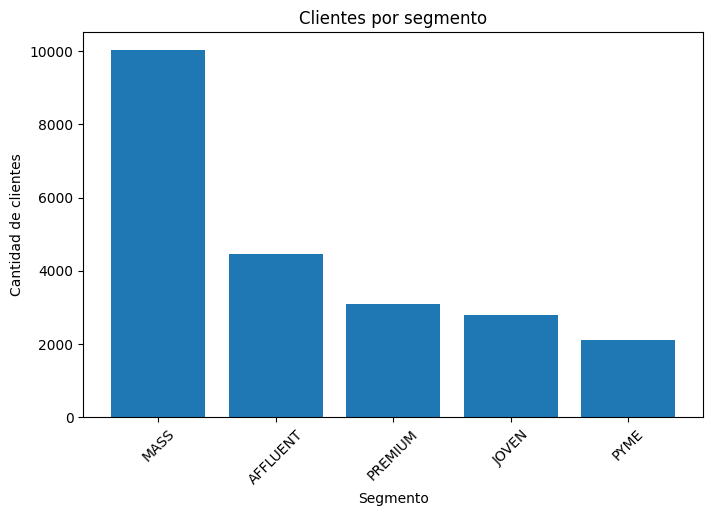

In [19]:
segmentos = df["segmento_cliente"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(segmentos.index.astype(str), segmentos.values)
plt.xlabel("Segmento")
plt.ylabel("Cantidad de clientes")
plt.title("Clientes por segmento")
plt.xticks(rotation=45)
plt.show()

In [20]:
df["ingreso_estimado"].describe()

,ingreso_estimado
count,22455.000000
mean,1881.730729
std,1539.290782
min,350.000000
25%,798.770000
50%,1255.170000
75%,2534.150000
max,16177.540000


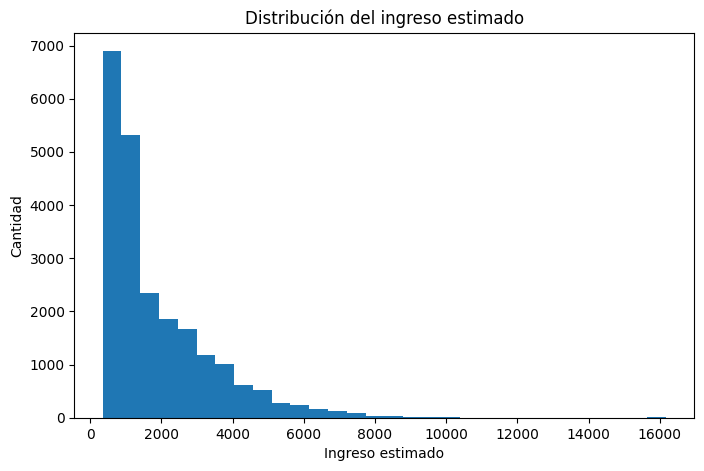

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df["ingreso_estimado"].dropna(), bins=30)
plt.xlabel("Ingreso estimado")
plt.ylabel("Cantidad")
plt.title("Distribución del ingreso estimado")
plt.show()

In [22]:
df["categoria_consumo"].value_counts(dropna=False)

,count
categoria_consumo,
NaN,7513
Supermarket,2221
Food,2171
Travel,1735
Streaming,1728
Technology,1668
Entertainment,1368
Others,1031
Health,995


In [23]:
df["categoria_consumo"] = (
    df["categoria_consumo"]
    .str.strip()
    .str.upper()
)

df["categoria_consumo"] = df["categoria_consumo"].replace({
    "FOOD": "FOOD",
    "STREAMNG": "STREAMING",
    "TRAVELS": "TRAVEL",
    "TECH": "TECHNOLOGY",
    "SUPER MARKET": "SUPERMARKET"
})

In [24]:
df["categoria_consumo"].value_counts(dropna=False)

,count
categoria_consumo,
NaN,7513
SUPERMARKET,2239
FOOD,2207
TRAVEL,1764
STREAMING,1758
TECHNOLOGY,1690
ENTERTAINMENT,1368
OTHERS,1031
HEALTH,995


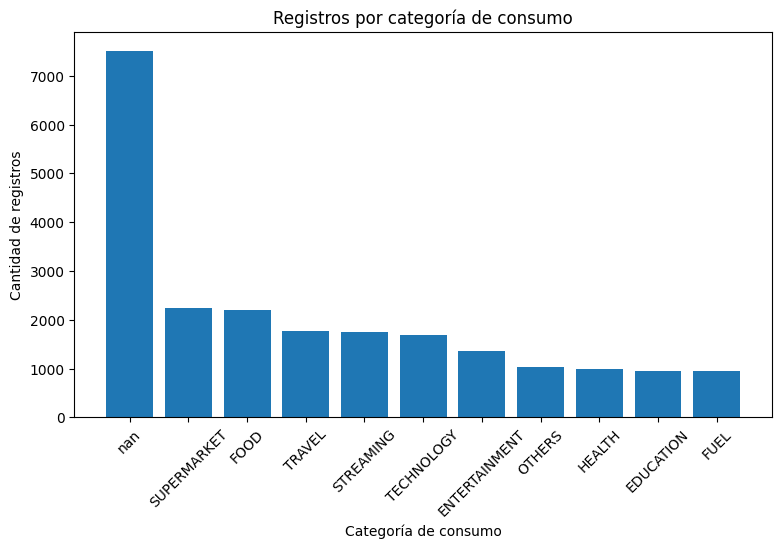

In [25]:
consumo = df["categoria_consumo"].value_counts(dropna=False)

plt.figure(figsize=(9, 5))
plt.bar(consumo.index.astype(str), consumo.values)
plt.xlabel("Categoría de consumo")
plt.ylabel("Cantidad de registros")
plt.title("Registros por categoría de consumo")
plt.xticks(rotation=45)
plt.show()

In [26]:
df["producto"].value_counts(dropna=False)

,count
producto,
Tarjeta de Crédito,14942
Cuenta de Ahorros,1741
Cuenta Corriente,1723
Crédito de Consumo,1439
Crédito Hipotecario,1378
Crédito Vehicular,1232


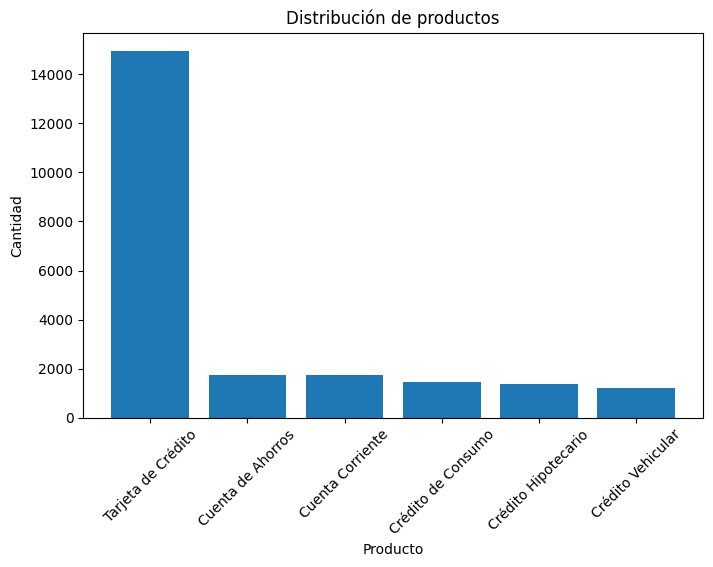

In [27]:
productos = df["producto"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(productos.index.astype(str), productos.values)
plt.xlabel("Producto")
plt.ylabel("Cantidad")
plt.title("Distribución de productos")
plt.xticks(rotation=45)
plt.show()

In [28]:
df["canal"].value_counts(dropna=False)

,count
canal,
POS,7373
App,5170
Web,4774
Branch,3965
ATM,1173


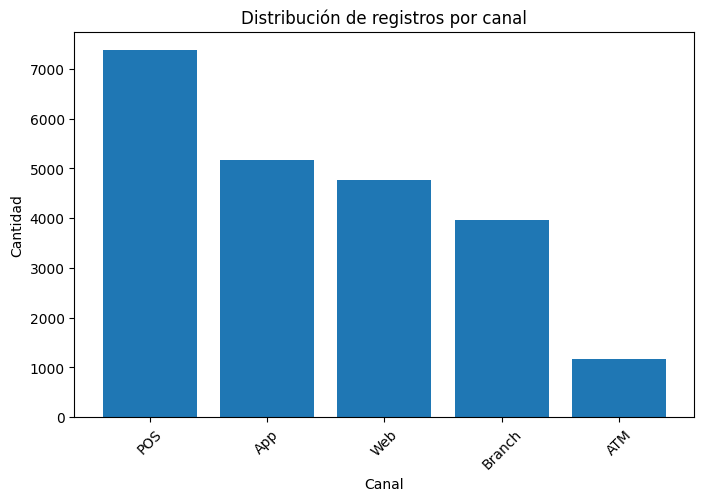

In [29]:
canales = df["canal"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(canales.index.astype(str), canales.values)
plt.xlabel("Canal")
plt.ylabel("Cantidad")
plt.title("Distribución de registros por canal")
plt.xticks(rotation=45)
plt.show()

In [30]:
df["estado_producto"].value_counts(dropna=False)

,count
estado_producto,
Activo,22455


In [31]:
analisis_cupo = (
    df.groupby(["cliente_id", "producto"])["cupo_credito"]
    .agg(
        registros="count",
        valores_unicos="nunique",
        minimo="min",
        maximo="max",
        promedio="mean"
    )
    .reset_index()
)

analisis_cupo.head(20)

,cliente_id,producto,registros,valores_unicos,minimo,maximo,promedio
0,C000001,Crédito de Consumo,0,0,NaN,NaN,NaN
1,C000001,Tarjeta de Crédito,10,1,6200.0,6200.0,6200.0
2,C000002,Crédito Hipotecario,0,0,NaN,NaN,NaN
3,C000002,Tarjeta de Crédito,5,1,800.0,800.0,800.0
4,C000003,Tarjeta de Crédito,7,1,6600.0,6600.0,6600.0
5,C000004,Cuenta de Ahorros,0,0,NaN,NaN,NaN
6,C000005,Crédito de Consumo,0,0,NaN,NaN,NaN
7,C000005,Cuenta de Ahorros,0,0,NaN,NaN,NaN
8,C000006,Crédito Vehicular,0,0,NaN,NaN,NaN
9,C000006,Crédito de Consumo,0,0,NaN,NaN,NaN


In [32]:
# Buscar el cupo conocido por cliente y producto
cupo_referencia = (
    df.groupby(["cliente_id", "producto"])["cupo_credito"]
    .transform("first")
)

# Cantidad de NaN que tienen un cupo de referencia
recuperables = (
    df["cupo_credito"].isna() &
    cupo_referencia.notna()
)

print("NaN recuperables:", recuperables.sum())
print("Total NaN:", df["cupo_credito"].isna().sum())
print(
    "Porcentaje recuperable:",
    round(recuperables.sum() / df["cupo_credito"].isna().sum() * 100, 2),
    "%"
)

NaN recuperables: 0
Total NaN: 7513
Porcentaje recuperable: 0.0 %


In [33]:
df[df["cliente_id"] == "C000001"][
    ["cliente_id", "producto", "cupo_credito"]
].sort_values("producto")

,cliente_id,producto,cupo_credito
14853,C000001,Crédito de Consumo,NaN
7789,C000001,Tarjeta de Crédito,6200.0
8760,C000001,Tarjeta de Crédito,6200.0
8830,C000001,Tarjeta de Crédito,6200.0
10182,C000001,Tarjeta de Crédito,6200.0
12677,C000001,Tarjeta de Crédito,6200.0
15425,C000001,Tarjeta de Crédito,6200.0
17058,C000001,Tarjeta de Crédito,6200.0
17367,C000001,Tarjeta de Crédito,6200.0
20063,C000001,Tarjeta de Crédito,6200.0


In [34]:
cupo_cliente = (
    df.groupby("cliente_id")["cupo_credito"]
    .agg(
        registros_con_cupo="count",
        valores_unicos="nunique",
        cupo_min="min",
        cupo_max="max"
    )
    .reset_index()
)

df_nan = df[df["cupo_credito"].isna()].copy()

prueba = df_nan.merge(
    cupo_cliente,
    on="cliente_id",
    how="left"
)

prueba.head(20)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,registros_con_cupo,valores_unicos,cupo_min,cupo_max
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NaN,0.0,Branch,Activo,4,1,1400.0,1400.0
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NaN,0.0,App,Activo,10,1,800.0,800.0
2,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NaN,0.0,App,Activo,6,1,2500.0,2500.0
3,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NaN,0.0,Web,Activo,13,1,2300.0,2300.0
4,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NaN,0.0,Web,Activo,8,1,1200.0,1200.0
5,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NaN,0.0,App,Activo,5,1,8700.0,8700.0
6,C001174,Cliente 1174,MASS,Guayaquil,42,729.85,Cuenta Corriente,1528.40,NaN,NaN,2026-04-13,NaN,0.0,Web,Activo,13,1,1700.0,1700.0
7,C002010,Cliente 2010,PREMIUM,Ambato,35,4058.22,Cuenta Corriente,6441.10,NaN,NaN,2025-08-20,NaN,0.0,ATM,Activo,6,1,10300.0,10300.0
8,C001604,Cliente 1604,MASS,Guayaquil,21,1058.16,Crédito Vehicular,23759.75,NaN,2030-08-21,2026-02-25,NaN,0.0,Branch,Activo,12,1,2000.0,2000.0
9,C002190,Cliente 2190,MASS,Quito,38,1141.09,Cuenta de Ahorros,2527.68,NaN,NaN,2025-06-09,NaN,0.0,Branch,Activo,4,1,2800.0,2800.0


In [35]:
cupo_referencia = (
    df.groupby(["cliente_id", "producto"])["cupo_credito"]
    .transform(lambda x: x.dropna().iloc[0] if x.notna().any() else None)
)

In [36]:
casos_recuperables = (
    df["cupo_credito"].isna() &
    cupo_referencia.notna()
)

In [37]:
print("NaN recuperables:", casos_recuperables.sum())
print("Total NaN:", df["cupo_credito"].isna().sum())

NaN recuperables: 0
Total NaN: 7513


In [38]:
df[df["cliente_id"] == "C000001"][[
    "cliente_id",
    "producto",
    "cupo_credito"
]]

,cliente_id,producto,cupo_credito
7789,C000001,Tarjeta de Crédito,6200.0
8760,C000001,Tarjeta de Crédito,6200.0
8830,C000001,Tarjeta de Crédito,6200.0
10182,C000001,Tarjeta de Crédito,6200.0
12677,C000001,Tarjeta de Crédito,6200.0
14853,C000001,Crédito de Consumo,NaN
15425,C000001,Tarjeta de Crédito,6200.0
17058,C000001,Tarjeta de Crédito,6200.0
17367,C000001,Tarjeta de Crédito,6200.0
20063,C000001,Tarjeta de Crédito,6200.0


In [39]:
df[
    (df["cliente_id"] == "C000001") &
    (df["cupo_credito"].notna())
][[
    "cliente_id",
    "producto",
    "cupo_credito"
]]

,cliente_id,producto,cupo_credito
7789,C000001,Tarjeta de Crédito,6200.0
8760,C000001,Tarjeta de Crédito,6200.0
8830,C000001,Tarjeta de Crédito,6200.0
10182,C000001,Tarjeta de Crédito,6200.0
12677,C000001,Tarjeta de Crédito,6200.0
15425,C000001,Tarjeta de Crédito,6200.0
17058,C000001,Tarjeta de Crédito,6200.0
17367,C000001,Tarjeta de Crédito,6200.0
20063,C000001,Tarjeta de Crédito,6200.0
21105,C000001,Tarjeta de Crédito,6200.0


In [40]:
cupo_referencia = (
    df.groupby(["cliente_id", "producto"])["cupo_credito"]
    .transform(lambda x: x.dropna().iloc[0] if x.notna().any() else None)
)

casos_recuperables = (
    df["cupo_credito"].isna() &
    cupo_referencia.notna()
)

df.loc[casos_recuperables, [
    "cliente_id",
    "producto",
    "cupo_credito"
]].head(30)

,cliente_id,producto,cupo_credito


In [41]:
print("NaN recuperables:", casos_recuperables.sum())

NaN recuperables: 0


In [42]:
df.groupby("producto")["cupo_credito"].agg(
    total_registros="size",
    registros_con_cupo="count",
    registros_sin_cupo=lambda x: x.isna().sum()
)

,total_registros,registros_con_cupo,registros_sin_cupo
producto,,,
Crédito Hipotecario,1378,0,1378
Crédito Vehicular,1232,0,1232
Crédito de Consumo,1439,0,1439
Cuenta Corriente,1723,0,1723
Cuenta de Ahorros,1741,0,1741
Tarjeta de Crédito,14942,14942,0


In [43]:
df[df["cupo_credito"].isna()]["producto"].value_counts()

,count
producto,
Cuenta de Ahorros,1741
Cuenta Corriente,1723
Crédito de Consumo,1439
Crédito Hipotecario,1378
Crédito Vehicular,1232


In [44]:
df["cupo_credito_aplica"] = df["producto"].eq("Tarjeta de Crédito")

In [45]:
df["cupo_credito_estado"] = df["cupo_credito"].notna().map({
    True: "CON CUPO",
    False: "NO APLICA"
})

In [46]:
analisis_cupo = (
    df.groupby(["cliente_id", "producto"])["cupo_credito"]
    .agg(
        registros="count",
        valores_unicos="nunique",
        minimo="min",
        maximo="max",
        promedio="mean"
    )
    .reset_index()
)

In [47]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_aplica,cupo_credito_estado
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NaN,0.00,Branch,Activo,False,NO APLICA
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NaN,0.00,App,Activo,False,NO APLICA
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,True,CON CUPO
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NaN,0.00,App,Activo,False,NO APLICA
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,True,CON CUPO
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NaN,0.00,Web,Activo,False,NO APLICA
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,True,CON CUPO
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,True,CON CUPO
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NaN,0.00,Web,Activo,False,NO APLICA
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NaN,0.00,App,Activo,False,NO APLICA


In [48]:
df["ciudad"].describe()

,ciudad
count,22277
unique,6
top,Guayaquil
freq,7918


In [49]:
df["ciudad"].value_counts()

,count
ciudad,
Guayaquil,7918
Quito,7118
Cuenca,2892
Manta,1772
Ambato,1488
Loja,1089


In [50]:
pd.crosstab(
    df["producto"],
    df["categoria_consumo"],
    dropna=False
)

categoria_consumo,EDUCATION,ENTERTAINMENT,FOOD,FUEL,HEALTH,OTHERS,STREAMING,SUPERMARKET,TECHNOLOGY,TRAVEL,NaN
producto,,,,,,,,,,,
Crédito Hipotecario,0,0,0,0,0,0,0,0,0,0,1378
Crédito Vehicular,0,0,0,0,0,0,0,0,0,0,1232
Crédito de Consumo,0,0,0,0,0,0,0,0,0,0,1439
Cuenta Corriente,0,0,0,0,0,0,0,0,0,0,1723
Cuenta de Ahorros,0,0,0,0,0,0,0,0,0,0,1741
Tarjeta de Crédito,947,1368,2207,943,995,1031,1758,2239,1690,1764,0


In [51]:
resumen = (
    df.groupby("producto", dropna=False)
      .agg(
          total_registros=("producto", "size"),
          registros_con_categoria=("categoria_consumo", lambda x: x.notna().sum()),
          registros_sin_categoria=("categoria_consumo", lambda x: x.isna().sum())
      )
      .reset_index()
)

resumen["%_sin_categoria"] = (
    resumen["registros_sin_categoria"] / resumen["total_registros"] * 100
).round(2)

resumen

,producto,total_registros,registros_con_categoria,registros_sin_categoria,%_sin_categoria
0,Crédito Hipotecario,1378,0,1378,100.0
1,Crédito Vehicular,1232,0,1232,100.0
2,Crédito de Consumo,1439,0,1439,100.0
3,Cuenta Corriente,1723,0,1723,100.0
4,Cuenta de Ahorros,1741,0,1741,100.0
5,Tarjeta de Crédito,14942,14942,0,0.0


In [52]:
df.groupby("producto")["monto_consumo"].agg(
    total_registros="count",
    suma="sum",
    minimo="min",
    maximo="max",
    promedio="mean"
)

,total_registros,suma,minimo,maximo,promedio
producto,,,,,
Crédito Hipotecario,1378,0.00,0.0,0.00,0.000000
Crédito Vehicular,1232,0.00,0.0,0.00,0.000000
Crédito de Consumo,1439,0.00,0.0,0.00,0.000000
Cuenta Corriente,1723,0.00,0.0,0.00,0.000000
Cuenta de Ahorros,1741,0.00,0.0,0.00,0.000000
Tarjeta de Crédito,14942,1871211.49,2.0,3712.08,125.231662


In [53]:
df.groupby("producto")["monto_consumo"].apply(
    lambda x: (x > 0).sum()
).sort_values(ascending=False)

,monto_consumo
producto,
Tarjeta de Crédito,14942
Crédito Hipotecario,0
Crédito Vehicular,0
Crédito de Consumo,0
Cuenta Corriente,0
Cuenta de Ahorros,0


In [54]:
df["categoria_consumo"] = df["categoria_consumo"].fillna("NO APLICA")

In [55]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_aplica,cupo_credito_estado
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NO APLICA,0.00,Branch,Activo,False,NO APLICA
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,False,NO APLICA
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,True,CON CUPO
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NO APLICA,0.00,App,Activo,False,NO APLICA
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,True,CON CUPO
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NO APLICA,0.00,Web,Activo,False,NO APLICA
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,True,CON CUPO
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,True,CON CUPO
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,False,NO APLICA
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,False,NO APLICA


In [56]:
pd.crosstab(
    df["producto"],
    df["fecha_vencimiento"].isna()
)

fecha_vencimiento,False,True
producto,,
Crédito Hipotecario,1378,0
Crédito Vehicular,1232,0
Crédito de Consumo,1439,0
Cuenta Corriente,0,1723
Cuenta de Ahorros,0,1741
Tarjeta de Crédito,14942,0


In [57]:
df.groupby("producto").agg(
    total_registros=("cliente_id", "size"),
    fecha_vencimiento_con_dato=("fecha_vencimiento", "count"),
    fecha_vencimiento_nula=("fecha_vencimiento", lambda x: x.isna().sum())
).reset_index()

,producto,total_registros,fecha_vencimiento_con_dato,fecha_vencimiento_nula
0,Crédito Hipotecario,1378,1378,0
1,Crédito Vehicular,1232,1232,0
2,Crédito de Consumo,1439,1439,0
3,Cuenta Corriente,1723,0,1723
4,Cuenta de Ahorros,1741,0,1741
5,Tarjeta de Crédito,14942,14942,0


In [58]:
df["aplica_fecha_vencimiento"] = ~df["producto"].isin([
    "Cuenta Corriente",
    "Cuenta de Ahorros"
])

In [59]:
df["aplica_fecha_vencimiento"] = df["producto"].isin([
    "Crédito Hipotecario",
    "Crédito Vehicular",
    "Crédito de Consumo",
    "Tarjeta de Crédito"
]).map({True: "SI", False: "NO"})

In [60]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_aplica,cupo_credito_estado,aplica_fecha_vencimiento
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NO APLICA,0.00,Branch,Activo,False,NO APLICA,NO
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,False,NO APLICA,SI
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,True,CON CUPO,SI
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NO APLICA,0.00,App,Activo,False,NO APLICA,NO
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,True,CON CUPO,SI
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NO APLICA,0.00,Web,Activo,False,NO APLICA,NO
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,True,CON CUPO,SI
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,True,CON CUPO,SI
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,False,NO APLICA,SI
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,False,NO APLICA,SI


In [61]:
df[df["ciudad"].isna()]["producto"].value_counts(dropna=False)

,count
producto,
Tarjeta de Crédito,132
Cuenta de Ahorros,15
Cuenta Corriente,12
Crédito Vehicular,9
Crédito Hipotecario,5
Crédito de Consumo,5


In [62]:
df.groupby("producto").agg(
    total_registros=("cliente_id", "size"),
    ciudad_con_dato=("ciudad", "count"),
    ciudad_nula=("ciudad", lambda x: x.isna().sum())
).reset_index()

,producto,total_registros,ciudad_con_dato,ciudad_nula
0,Crédito Hipotecario,1378,1373,5
1,Crédito Vehicular,1232,1223,9
2,Crédito de Consumo,1439,1434,5
3,Cuenta Corriente,1723,1711,12
4,Cuenta de Ahorros,1741,1726,15
5,Tarjeta de Crédito,14942,14810,132


In [63]:
clientes_con_ciudad = (
    df.groupby("cliente_id")["ciudad"]
      .agg(
          registros="size",
          ciudades_con_dato="count",
          ciudades_nulas=lambda x: x.isna().sum()
      )
      .reset_index()
)

clientes_con_ciudad[
    (clientes_con_ciudad["ciudades_nulas"] > 0) &
    (clientes_con_ciudad["ciudades_con_dato"] > 0)
]

,cliente_id,registros,ciudades_con_dato,ciudades_nulas
6,C000007,8,7,1
80,C000081,9,8,1
110,C000111,5,4,1
114,C000115,13,12,1
120,C000121,14,13,1
...,...,...,...,...
2155,C002156,7,6,1
2159,C002160,13,12,1
2188,C002189,11,10,1
2193,C002194,9,8,1


In [64]:
ciudades_por_cliente = (
    df.groupby("cliente_id")["ciudad"]
      .agg(
          ciudades_unicas=lambda x: x.dropna().unique().tolist(),
          cantidad_ciudades=lambda x: x.dropna().nunique(),
          ciudades_nulas=lambda x: x.isna().sum()
      )
      .reset_index()
)

ciudades_por_cliente[
    (ciudades_por_cliente["ciudades_nulas"] > 0) &
    (ciudades_por_cliente["cantidad_ciudades"] > 0)
]

,cliente_id,ciudades_unicas,cantidad_ciudades,ciudades_nulas
6,C000007,[Quito],1,1
80,C000081,[Guayaquil],1,1
110,C000111,[Quito],1,1
114,C000115,[Manta],1,1
120,C000121,[Quito],1,1
...,...,...,...,...
2155,C002156,[Guayaquil],1,1
2159,C002160,[Guayaquil],1,1
2188,C002189,[Quito],1,1
2193,C002194,[Quito],1,1


In [65]:
ciudades_por_cliente = (
    df.groupby("cliente_id")["ciudad"]
      .agg(
          ciudades_unicas=lambda x: x.dropna().unique().tolist(),
          cantidad_ciudades=lambda x: x.dropna().nunique(),
          ciudades_nulas=lambda x: x.isna().sum()
      )
      .reset_index()
)

In [66]:
casos_seguros = ciudades_por_cliente[
    (ciudades_por_cliente["ciudades_nulas"] > 0) &
    (ciudades_por_cliente["cantidad_ciudades"] == 1)
].copy()

In [67]:
casos_no_recuperables = df[
    df["ciudad"].isna() &
    ~df["cliente_id"].isin(casos_seguros["cliente_id"])
]

casos_no_recuperables[
    ["cliente_id", "nombre_cliente", "producto", "ciudad"]
]

,cliente_id,nombre_cliente,producto,ciudad
6180,C001036,Cliente 1036,Crédito de Consumo,NaN


In [68]:
df["ciudad"].isna().sum()

np.int64(178)

In [69]:
nulos_ciudad = df[df["ciudad"].isna()][
    ["cliente_id", "nombre_cliente", "producto", "ciudad"]
]

nulos_ciudad

,cliente_id,nombre_cliente,producto,ciudad
85,C000081,Cliente 0081,Crédito Hipotecario,NaN
198,C001685,Cliente 1685,Tarjeta de Crédito,NaN
313,C000415,Cliente 0415,Tarjeta de Crédito,NaN
403,C001035,Cliente 1035,Cuenta Corriente,NaN
512,C000383,Cliente 0383,Tarjeta de Crédito,NaN
...,...,...,...,...
21704,C001123,Cliente 1123,Tarjeta de Crédito,NaN
21993,C002196,Cliente 2196,Tarjeta de Crédito,NaN
22080,C001934,Cliente 1934,Tarjeta de Crédito,NaN
22221,C001625,Cliente 1625,Tarjeta de Crédito,NaN


In [70]:
ciudades_por_cliente = (
    df.groupby("cliente_id")["ciudad"]
      .agg(
          ciudades_unicas=lambda x: x.dropna().unique().tolist(),
          cantidad_ciudades=lambda x: x.dropna().nunique(),
          ciudades_nulas=lambda x: x.isna().sum()
      )
      .reset_index()
)

In [71]:
# Obtener las ciudades conocidas de cada cliente
ciudades_por_cliente = (
    df.groupby("cliente_id")["ciudad"]
      .agg(lambda x: x.dropna().unique().tolist())
)

# Crear columna de validación
df["ciudad_validacion"] = df["cliente_id"].map(
    lambda x: ciudades_por_cliente[x][0]
    if len(ciudades_por_cliente[x]) == 1
    else None
)

In [72]:
df[
    df["ciudad"].isna() &
    df["ciudad_validacion"].notna()
][
    ["cliente_id", "nombre_cliente", "producto", "ciudad", "ciudad_validacion"]
]

,cliente_id,nombre_cliente,producto,ciudad,ciudad_validacion
85,C000081,Cliente 0081,Crédito Hipotecario,NaN,Guayaquil
198,C001685,Cliente 1685,Tarjeta de Crédito,NaN,Quito
313,C000415,Cliente 0415,Tarjeta de Crédito,NaN,Quito
403,C001035,Cliente 1035,Cuenta Corriente,NaN,Quito
512,C000383,Cliente 0383,Tarjeta de Crédito,NaN,Guayaquil
...,...,...,...,...,...
21704,C001123,Cliente 1123,Tarjeta de Crédito,NaN,Guayaquil
21993,C002196,Cliente 2196,Tarjeta de Crédito,NaN,Ambato
22080,C001934,Cliente 1934,Tarjeta de Crédito,NaN,Quito
22221,C001625,Cliente 1625,Tarjeta de Crédito,NaN,Loja


In [73]:
print(
    "Registros que podemos validar:",
    df["ciudad_validacion"].notna().sum()
)

Registros que podemos validar: 22454


In [74]:
print(
    "Nulos de ciudad recuperables:",
    (
        df["ciudad"].isna() &
        df["ciudad_validacion"].notna()
    ).sum()
)

Nulos de ciudad recuperables: 177


In [75]:
df[df["cliente_id"] == "C001036"][
    ["cliente_id", "nombre_cliente", "producto", "ciudad"]
]

,cliente_id,nombre_cliente,producto,ciudad
6180,C001036,Cliente 1036,Crédito de Consumo,NaN


In [76]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_aplica,cupo_credito_estado,aplica_fecha_vencimiento,ciudad_validacion
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NO APLICA,0.00,Branch,Activo,False,NO APLICA,NO,Loja
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,False,NO APLICA,SI,Guayaquil
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,True,CON CUPO,SI,Manta
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NO APLICA,0.00,App,Activo,False,NO APLICA,NO,Guayaquil
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,True,CON CUPO,SI,Guayaquil
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NO APLICA,0.00,Web,Activo,False,NO APLICA,NO,Cuenca
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,True,CON CUPO,SI,Ambato
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,True,CON CUPO,SI,Quito
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,False,NO APLICA,SI,Quito
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,False,NO APLICA,SI,Quito


In [77]:
# Marcar inicialmente todos como NO imputados
df["ciudad_imputada"] = "NO"

# Identificar los 177 registros recuperables
mask = (
    df["ciudad"].isna() &
    df["ciudad_validacion"].notna()
)

# Reemplazar ciudad
df.loc[mask, "ciudad"] = df.loc[mask, "ciudad_validacion"]

# Marcar los registros que fueron completados
df.loc[mask, "ciudad_imputada"] = "SI"

In [78]:
print("Ciudades nulas restantes:", df["ciudad"].isna().sum())
print("Registros imputados:", (df["ciudad_imputada"] == "SI").sum())

Ciudades nulas restantes: 1
Registros imputados: 177


In [79]:
df[df["ciudad"].isna()][
    ["cliente_id", "nombre_cliente", "producto", "ciudad", "ciudad_imputada"]
]

,cliente_id,nombre_cliente,producto,ciudad,ciudad_imputada
6180,C001036,Cliente 1036,Crédito de Consumo,NaN,NO


In [112]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_estado,aplica_fecha_vencimiento,primer_movimiento_cliente_producto,categoria_saldo
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NO APLICA,0.00,Branch,Activo,NO APLICA,NO,2025-12-08,VALIDADO - HISTÓRICO DISPONIBLE
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-02-02,VALIDADO - HISTÓRICO DISPONIBLE
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,CON CUPO,SI,2025-01-28,VALIDADO - HISTÓRICO DISPONIBLE
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NO APLICA,0.00,App,Activo,NO APLICA,NO,2025-06-09,VALIDADO - HISTÓRICO DISPONIBLE
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,CON CUPO,SI,2025-01-18,VALIDADO - HISTÓRICO DISPONIBLE
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NO APLICA,0.00,Web,Activo,NO APLICA,NO,2025-07-28,VALIDADO - HISTÓRICO DISPONIBLE
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,CON CUPO,SI,2025-03-08,VALIDADO - HISTÓRICO DISPONIBLE
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,CON CUPO,SI,2025-04-29,VALIDADO - HISTÓRICO DISPONIBLE
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,NO APLICA,SI,2025-10-03,VALIDADO - HISTÓRICO DISPONIBLE
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-11-21,VALIDADO - HISTÓRICO DISPONIBLE


In [113]:
saldo_por_producto = (
    df.groupby("producto")["saldo_producto"]
      .agg(
          total_registros="size",
          saldo_con_dato="count",
          saldo_nulo=lambda x: x.isna().sum(),
          minimo="min",
          maximo="max",
          promedio="mean"
      )
      .reset_index()
)

saldo_por_producto

,producto,total_registros,saldo_con_dato,saldo_nulo,minimo,maximo,promedio
0,Crédito Hipotecario,1378,1377,1,0.0,158165.51,74435.594749
1,Crédito Vehicular,1232,1230,2,0.0,38261.64,18091.094797
2,Crédito de Consumo,1439,1436,3,115.3,43034.16,8953.807806
3,Cuenta Corriente,1723,1721,2,-100.0,35349.58,4269.791046
4,Cuenta de Ahorros,1741,1741,0,-100.0,49425.12,4480.902338
5,Tarjeta de Crédito,14942,14942,0,0.0,18157.12,1215.689669


In [114]:
saldo_cliente_producto = (
    df.groupby(["cliente_id", "producto"])["saldo_producto"]
      .agg(
          registros="size",
          saldos_con_dato="count",
          saldos_nulos=lambda x: x.isna().sum(),
          saldos_unicos=lambda x: x.dropna().unique().tolist()
      )
      .reset_index()
)

saldo_cliente_producto[
    (saldo_cliente_producto["saldos_nulos"] > 0) &
    (saldo_cliente_producto["saldos_con_dato"] > 0)
]

,cliente_id,producto,registros,saldos_con_dato,saldos_nulos,saldos_unicos


In [82]:
# Obtener los saldos conocidos por cliente + producto
saldo_por_cliente_producto = (
    df.groupby(["cliente_id", "producto"])["saldo_producto"]
      .agg(lambda x: x.dropna().unique().tolist())
)

# Crear columna de validación
df["saldo_validacion"] = df.apply(
    lambda row: (
        saldo_por_cliente_producto.get(
            (row["cliente_id"], row["producto"]), []
        )[0]
        if len(saldo_por_cliente_producto.get(
            (row["cliente_id"], row["producto"]), []
        )) == 1
        else None
    ),
    axis=1
)

In [83]:
df[
    df["saldo_producto"].isna() &
    df["saldo_validacion"].notna()
][
    [
        "cliente_id",
        "nombre_cliente",
        "producto",
        "saldo_producto",
        "saldo_validacion"
    ]
]

,cliente_id,nombre_cliente,producto,saldo_producto,saldo_validacion
105,C001237,Cliente 1237,Tarjeta de Crédito,NaN,844.27
305,C001137,Cliente 1137,Tarjeta de Crédito,NaN,2006.67
475,C001952,Cliente 1952,Tarjeta de Crédito,NaN,622.74
484,C001477,Cliente 1477,Tarjeta de Crédito,NaN,1708.28
757,C000082,Cliente 0082,Cuenta de Ahorros,NaN,35.53
...,...,...,...,...,...
21255,C001788,Cliente 1788,Tarjeta de Crédito,NaN,598.30
21351,C001289,Cliente 1289,Cuenta Corriente,NaN,1968.30
21587,C000073,Cliente 0073,Tarjeta de Crédito,NaN,4193.81
21668,C001895,Cliente 1895,Tarjeta de Crédito,NaN,2314.82


In [84]:
(
    df["saldo_producto"].isna() &
    df["saldo_validacion"].notna()
).sum()

np.int64(128)

In [85]:
saldo_cliente_producto = (
    df.groupby(["cliente_id", "producto"])["saldo_producto"]
      .agg(
          saldos_unicos=lambda x: x.dropna().unique().tolist(),
          cantidad_saldos=lambda x: x.dropna().nunique(),
          nulos=lambda x: x.isna().sum()
      )
      .reset_index()
)

saldo_cliente_producto[
    (saldo_cliente_producto["nulos"] > 0) &
    (saldo_cliente_producto["cantidad_saldos"] > 1)
]

,cliente_id,producto,saldos_unicos,cantidad_saldos,nulos


In [86]:
df["saldo_imputado"] = "NO"

mask_saldo = (
    df["saldo_producto"].isna() &
    df["saldo_validacion"].notna()
)

df.loc[mask_saldo, "saldo_producto"] = df.loc[
    mask_saldo, "saldo_validacion"
]

df.loc[mask_saldo, "saldo_imputado"] = "SI"

In [87]:
print("Saldos imputados:", (df["saldo_imputado"] == "SI").sum())
print("Saldos nulos restantes:", df["saldo_producto"].isna().sum())

Saldos imputados: 128
Saldos nulos restantes: 8


In [88]:
df[
    df["saldo_producto"].isna()
][
    [
        "cliente_id",
        "nombre_cliente",
        "producto",
        "saldo_producto",
        "saldo_validacion"
    ]
]

,cliente_id,nombre_cliente,producto,saldo_producto,saldo_validacion
278,C000058,Cliente 0058,Crédito Hipotecario,NaN,NaN
734,C001433,Cliente 1433,Crédito Vehicular,NaN,NaN
2756,C000866,Cliente 0866,Cuenta Corriente,NaN,NaN
6180,C001036,Cliente 1036,Crédito de Consumo,NaN,NaN
10199,C000580,Cliente 0580,Crédito de Consumo,NaN,NaN
10608,C001641,Cliente 1641,Cuenta Corriente,NaN,NaN
17830,C000963,Cliente 0963,Crédito Vehicular,NaN,NaN
22100,C001299,Cliente 1299,Crédito de Consumo,NaN,NaN


In [89]:
clientes_saldo_sin_dato = df[
    df["saldo_producto"].isna()
]["cliente_id"].unique()

df[
    df["cliente_id"].isin(clientes_saldo_sin_dato)
].sort_values(["cliente_id", "producto"])[
    [
        "cliente_id",
        "nombre_cliente",
        "producto",
        "saldo_producto"
    ]
]

,cliente_id,nombre_cliente,producto,saldo_producto
278,C000058,Cliente 0058,Crédito Hipotecario,NaN
18305,C000058,Cliente 0058,Crédito Vehicular,18379.68
8114,C000058,Cliente 0058,Cuenta Corriente,4057.82
20015,C000058,Cliente 0058,Cuenta Corriente,4057.82
315,C000058,Cliente 0058,Tarjeta de Crédito,0.00
...,...,...,...,...
15447,C001641,Cliente 1641,Tarjeta de Crédito,3218.04
16288,C001641,Cliente 1641,Tarjeta de Crédito,3218.04
16935,C001641,Cliente 1641,Tarjeta de Crédito,3218.04
18565,C001641,Cliente 1641,Tarjeta de Crédito,3218.04


In [90]:
clientes_8 = [
    "C000058",
    "C001433",
    "C000866",
    "C001036",
    "C000580",
    "C001641",
    "C000963",
    "C001299"
]

df[df["cliente_id"].isin(clientes_8)].sort_values(
    ["cliente_id", "producto", "fecha_movimiento"]
)[
    [
        "cliente_id",
        "nombre_cliente",
        "producto",
        "saldo_producto",
        "fecha_movimiento"
    ]
]

,cliente_id,nombre_cliente,producto,saldo_producto,fecha_movimiento
278,C000058,Cliente 0058,Crédito Hipotecario,NaN,2026-03-22
18305,C000058,Cliente 0058,Crédito Vehicular,18379.68,2025-06-21
20015,C000058,Cliente 0058,Cuenta Corriente,4057.82,2025-03-10
8114,C000058,Cliente 0058,Cuenta Corriente,4057.82,2025-09-22
15125,C000058,Cliente 0058,Tarjeta de Crédito,0.00,2025-01-13
...,...,...,...,...,...
18565,C001641,Cliente 1641,Tarjeta de Crédito,3218.04,2026-05-03
9589,C001641,Cliente 1641,Tarjeta de Crédito,3218.04,2026-06-02
16935,C001641,Cliente 1641,Tarjeta de Crédito,3218.04,2026-06-04
8965,C001641,Cliente 1641,Tarjeta de Crédito,3218.04,2026-08-15


In [91]:
casos_8 = df[
    df["saldo_producto"].isna() &
    df["cliente_id"].isin(clientes_8)
][
    ["cliente_id", "nombre_cliente", "producto", "saldo_producto", "fecha_movimiento"]
]

casos_8

,cliente_id,nombre_cliente,producto,saldo_producto,fecha_movimiento
278,C000058,Cliente 0058,Crédito Hipotecario,NaN,2026-03-22
734,C001433,Cliente 1433,Crédito Vehicular,NaN,2025-05-12
2756,C000866,Cliente 0866,Cuenta Corriente,NaN,2026-05-26
6180,C001036,Cliente 1036,Crédito de Consumo,NaN,2026-08-08
10199,C000580,Cliente 0580,Crédito de Consumo,NaN,2026-05-18
10608,C001641,Cliente 1641,Cuenta Corriente,NaN,2026-05-28
17830,C000963,Cliente 0963,Crédito Vehicular,NaN,2025-07-29
22100,C001299,Cliente 1299,Crédito de Consumo,NaN,2026-01-11


In [92]:
# Primer movimiento para cada cliente + producto
df["primer_movimiento_cliente_producto"] = (
    df.groupby(["cliente_id", "producto"])["fecha_movimiento"]
      .transform("min")
)

# Revisar los 8 casos
casos_8 = df[
    df["saldo_producto"].isna() &
    df["cliente_id"].isin(clientes_8)
][
    [
        "cliente_id",
        "nombre_cliente",
        "producto",
        "saldo_producto",
        "fecha_movimiento",
        "primer_movimiento_cliente_producto"
    ]
].copy()

casos_8["es_primer_movimiento"] = (
    casos_8["fecha_movimiento"] ==
    casos_8["primer_movimiento_cliente_producto"]
)

casos_8

,cliente_id,nombre_cliente,producto,saldo_producto,fecha_movimiento,primer_movimiento_cliente_producto,es_primer_movimiento
278,C000058,Cliente 0058,Crédito Hipotecario,NaN,2026-03-22,2026-03-22,True
734,C001433,Cliente 1433,Crédito Vehicular,NaN,2025-05-12,2025-05-12,True
2756,C000866,Cliente 0866,Cuenta Corriente,NaN,2026-05-26,2026-05-26,True
6180,C001036,Cliente 1036,Crédito de Consumo,NaN,2026-08-08,2026-08-08,True
10199,C000580,Cliente 0580,Crédito de Consumo,NaN,2026-05-18,2026-05-18,True
10608,C001641,Cliente 1641,Cuenta Corriente,NaN,2026-05-28,2026-05-28,True
17830,C000963,Cliente 0963,Crédito Vehicular,NaN,2025-07-29,2025-07-29,True
22100,C001299,Cliente 1299,Crédito de Consumo,NaN,2026-01-11,2026-01-11,True


In [93]:
df[
    df["cliente_id"].isin(clientes_8)
].groupby(["cliente_id", "producto"]).agg(
    registros=("saldo_producto", "size"),
    saldos_conocidos=("saldo_producto", "count"),
    fecha_min=("fecha_movimiento", "min"),
    fecha_max=("fecha_movimiento", "max")
).reset_index()

,cliente_id,producto,registros,saldos_conocidos,fecha_min,fecha_max
0,C000058,Crédito Hipotecario,1,0,2026-03-22,2026-03-22
1,C000058,Crédito Vehicular,1,1,2025-06-21,2025-06-21
2,C000058,Cuenta Corriente,2,2,2025-03-10,2025-09-22
3,C000058,Tarjeta de Crédito,11,11,2025-01-13,2026-08-09
4,C000580,Crédito Vehicular,3,3,2025-04-21,2025-07-22
5,C000580,Crédito de Consumo,1,0,2026-05-18,2026-05-18
6,C000580,Cuenta de Ahorros,4,4,2025-04-11,2025-12-17
7,C000580,Tarjeta de Crédito,12,12,02/10/2025,2026-08-05
8,C000866,Cuenta Corriente,1,0,2026-05-26,2026-05-26
9,C000866,Cuenta de Ahorros,2,2,2025-09-26,2026-05-05


In [94]:
saldo_cliente_producto["saldo_validacion"] = None

mask_sin_historico = (
    (saldo_cliente_producto["nulos"] == 1) &
    (saldo_cliente_producto["cantidad_saldos"] == 0)
)

saldo_cliente_producto.loc[
    mask_sin_historico,
    "saldo_validacion"
] = "PRODUCTO NUEVO - SIN HISTÓRICO"

In [95]:
df = df.merge(
    saldo_cliente_producto[
        ["cliente_id", "producto", "saldo_validacion"]
    ],
    on=["cliente_id", "producto"],
    how="left"
)

In [96]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,...,estado_producto,cupo_credito_aplica,cupo_credito_estado,aplica_fecha_vencimiento,ciudad_validacion,ciudad_imputada,saldo_validacion_x,saldo_imputado,primer_movimiento_cliente_producto,saldo_validacion_y
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,...,Activo,False,NO APLICA,NO,Loja,NO,1498.82,NO,2025-12-08,None
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,...,Activo,False,NO APLICA,SI,Guayaquil,NO,20725.80,NO,2025-02-02,None
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,...,Activo,True,CON CUPO,SI,Manta,NO,689.27,NO,2025-01-28,None
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,...,Activo,False,NO APLICA,NO,Guayaquil,NO,5001.88,NO,2025-06-09,None
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,...,Activo,True,CON CUPO,SI,Guayaquil,NO,1955.00,NO,2025-01-18,None
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,...,Activo,False,NO APLICA,NO,Cuenca,NO,4082.56,NO,2025-07-28,None
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,...,Activo,True,CON CUPO,SI,Ambato,NO,649.01,NO,2025-03-08,None
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,...,Activo,True,CON CUPO,SI,Quito,NO,363.70,NO,2025-04-29,None
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,...,Activo,False,NO APLICA,SI,Quito,NO,63176.59,NO,2025-10-03,None
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,...,Activo,False,NO APLICA,SI,Quito,NO,17442.60,NO,2025-11-21,None


In [97]:
df[df["cliente_id"] == "C001036"]["ciudad"].dropna().unique()

array([], dtype=object)

In [98]:
df[df["cliente_id"] == "C001036"].groupby("producto").agg(
    registros=("cliente_id", "size"),
    ciudades=("ciudad", lambda x: x.dropna().unique().tolist()),
    nulos_ciudad=("ciudad", lambda x: x.isna().sum())
).reset_index()

,producto,registros,ciudades,nulos_ciudad
0,Crédito de Consumo,1,[],1


In [100]:
columnas_eliminar = [
    "cupo_credito_aplica",
    "ciudad_validacion",
    "ciudad_imputada",
    "saldo_validacion_x",
    "saldo_imputado",
    "saldo_validacion_y"
]

df = df.drop(
    columns=[col for col in columnas_eliminar if col in df.columns]
)

In [101]:
df["saldo_validado"] = df["saldo_producto"]

In [102]:
casos_sin_historico = [
    ("C000058", "Crédito Hipotecario"),
    ("C001433", "Crédito Vehicular"),
    ("C000866", "Cuenta Corriente"),
    ("C001036", "Crédito de Consumo"),
    ("C000580", "Crédito de Consumo"),
    ("C001641", "Cuenta Corriente"),
    ("C000963", "Crédito Vehicular"),
    ("C001299", "Crédito de Consumo")
]

In [ ]:
df["categoria_saldo"] = "SIN INFORMACIÓN"

In [103]:
mask_sin_historico = df.apply(
    lambda row: (row["cliente_id"], row["producto"]) in casos_sin_historico,
    axis=1
)

df.loc[
    mask_sin_historico,
    "categoria_saldo"
] = "SIN HISTÓRICO - PRODUCTO NUEVO"

In [104]:
df.loc[
    df["saldo_producto"].notna(),
    "categoria_saldo"
] = "VALIDADO - HISTÓRICO DISPONIBLE"

In [105]:
df["saldo_validado"] = df["saldo_producto"]

In [106]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_estado,aplica_fecha_vencimiento,primer_movimiento_cliente_producto,saldo_validado,categoria_saldo
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NO APLICA,0.00,Branch,Activo,NO APLICA,NO,2025-12-08,1498.82,VALIDADO - HISTÓRICO DISPONIBLE
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-02-02,20725.80,VALIDADO - HISTÓRICO DISPONIBLE
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,CON CUPO,SI,2025-01-28,689.27,VALIDADO - HISTÓRICO DISPONIBLE
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NO APLICA,0.00,App,Activo,NO APLICA,NO,2025-06-09,5001.88,VALIDADO - HISTÓRICO DISPONIBLE
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,CON CUPO,SI,2025-01-18,1955.00,VALIDADO - HISTÓRICO DISPONIBLE
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NO APLICA,0.00,Web,Activo,NO APLICA,NO,2025-07-28,4082.56,VALIDADO - HISTÓRICO DISPONIBLE
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,CON CUPO,SI,2025-03-08,649.01,VALIDADO - HISTÓRICO DISPONIBLE
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,CON CUPO,SI,2025-04-29,363.70,VALIDADO - HISTÓRICO DISPONIBLE
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,NO APLICA,SI,2025-10-03,63176.59,VALIDADO - HISTÓRICO DISPONIBLE
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-11-21,17442.60,VALIDADO - HISTÓRICO DISPONIBLE


In [107]:
if "saldo_validado" in df.columns:
    df = df.drop(columns=["saldo_validado"])

In [108]:
nulos = df.isna().sum().sort_values(ascending=False)

nulos = nulos[nulos > 0]

nulos

,0
cupo_credito,7513
fecha_vencimiento,3464
saldo_producto,8
ciudad,1


In [111]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_estado,aplica_fecha_vencimiento,primer_movimiento_cliente_producto,categoria_saldo
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,NaN,NaN,2026-01-15,NO APLICA,0.00,Branch,Activo,NO APLICA,NO,2025-12-08,VALIDADO - HISTÓRICO DISPONIBLE
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,NaN,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-02-02,VALIDADO - HISTÓRICO DISPONIBLE
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,CON CUPO,SI,2025-01-28,VALIDADO - HISTÓRICO DISPONIBLE
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,NaN,NaN,2025-06-09,NO APLICA,0.00,App,Activo,NO APLICA,NO,2025-06-09,VALIDADO - HISTÓRICO DISPONIBLE
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,CON CUPO,SI,2025-01-18,VALIDADO - HISTÓRICO DISPONIBLE
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,NaN,NaN,2025-07-28,NO APLICA,0.00,Web,Activo,NO APLICA,NO,2025-07-28,VALIDADO - HISTÓRICO DISPONIBLE
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,CON CUPO,SI,2025-03-08,VALIDADO - HISTÓRICO DISPONIBLE
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,CON CUPO,SI,2025-04-29,VALIDADO - HISTÓRICO DISPONIBLE
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,NaN,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,NO APLICA,SI,2025-10-03,VALIDADO - HISTÓRICO DISPONIBLE
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,NaN,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-11-21,VALIDADO - HISTÓRICO DISPONIBLE


In [115]:
for col in ["fecha_movimiento", "fecha_vencimiento", "primer_movimiento_cliente_producto"]:
    iso = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")
    dmy = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")
    df[col] = iso.fillna(dmy)

df[["fecha_movimiento", "fecha_vencimiento", "primer_movimiento_cliente_producto"]].dtypes

,0
fecha_movimiento,datetime64[ns]
fecha_vencimiento,datetime64[ns]
primer_movimiento_cliente_producto,datetime64[ns]


In [116]:
print("Fecha mínima:", df["fecha_movimiento"].min())
print("Fecha máxima:", df["fecha_movimiento"].max())

Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2026-08-31 00:00:00


In [117]:
fecha_corte = df["fecha_movimiento"].max()

fecha_corte

Timestamp('2026-08-31 00:00:00')

In [118]:
segmentos_por_cliente = df.groupby("cliente_id")["segmento_cliente"].nunique()

segmentos_por_cliente.value_counts()

,count
segmento_cliente,
1,1989
2,206
3,5


In [119]:
multi = segmentos_por_cliente[segmentos_por_cliente > 1].index

df[df["cliente_id"].isin(multi)].sort_values(
    ["cliente_id", "fecha_movimiento"]
)[["cliente_id", "fecha_movimiento", "segmento_cliente"]].head(10)

,cliente_id,fecha_movimiento,segmento_cliente
15425,C000001,2025-02-27,AFFLUENT
8760,C000001,2025-03-15,MASS
17058,C000001,2025-04-10,AFFLUENT
12677,C000001,2025-06-16,AFFLUENT
17367,C000001,2025-08-14,AFFLUENT
14853,C000001,2025-08-27,AFFLUENT
21105,C000001,2025-10-12,AFFLUENT
7789,C000001,2025-10-24,AFFLUENT
20063,C000001,2026-01-06,AFFLUENT
8830,C000001,2026-01-24,AFFLUENT


In [120]:
segmento_vigente = (
    df.sort_values("fecha_movimiento")
      .groupby("cliente_id")["segmento_cliente"]
      .last()
)

df["segmento_cliente"] = df["cliente_id"].map(segmento_vigente)

df.groupby("cliente_id")["segmento_cliente"].nunique().value_counts()

,count
segmento_cliente,
1,2200


In [121]:
print("Edad fuera de 18-100:", ((df["edad"] < 18) | (df["edad"] > 100)).sum())
print("Monto negativo:", (df["monto_consumo"] < 0).sum())
print("Saldo negativo:", (df["saldo_producto"] < 0).sum())

Edad fuera de 18-100: 0
Monto negativo: 0
Saldo negativo: 304


In [122]:
df[df["saldo_producto"] < 0]["producto"].value_counts()

,count
producto,
Cuenta Corriente,153
Cuenta de Ahorros,151


In [123]:
df[df["saldo_producto"] < 0]["producto"].value_counts()

,count
producto,
Cuenta Corriente,153
Cuenta de Ahorros,151


In [124]:
df[df.duplicated(keep=False)].sort_values(
    ["cliente_id", "fecha_movimiento"]
).head(6)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_estado,aplica_fecha_vencimiento,primer_movimiento_cliente_producto,categoria_saldo
20090,C000030,Cliente 0030,JOVEN,Quito,37,1002.91,Tarjeta de Crédito,0.00,2400.0,2026-11-19,2026-01-24,FUEL,40.20,POS,Activo,CON CUPO,SI,2025-04-23,VALIDADO - HISTÓRICO DISPONIBLE
22006,C000030,Cliente 0030,JOVEN,Quito,37,1002.91,Tarjeta de Crédito,0.00,2400.0,2026-11-19,2026-01-24,FUEL,40.20,POS,Activo,CON CUPO,SI,2025-04-23,VALIDADO - HISTÓRICO DISPONIBLE
6456,C000052,Cliente 0052,MASS,Cuenca,47,492.23,Tarjeta de Crédito,322.65,700.0,2027-11-29,2025-08-13,TRAVEL,44.53,POS,Activo,CON CUPO,SI,2025-08-13,VALIDADO - HISTÓRICO DISPONIBLE
13682,C000052,Cliente 0052,MASS,Cuenca,47,492.23,Tarjeta de Crédito,322.65,700.0,2027-11-29,2025-08-13,TRAVEL,44.53,POS,Activo,CON CUPO,SI,2025-08-13,VALIDADO - HISTÓRICO DISPONIBLE
5974,C000066,Cliente 0066,MASS,Cuenca,18,1104.18,Tarjeta de Crédito,429.30,2100.0,2030-04-23,2025-08-22,FUEL,43.82,POS,Activo,CON CUPO,SI,2025-03-06,VALIDADO - HISTÓRICO DISPONIBLE
17048,C000066,Cliente 0066,MASS,Cuenca,18,1104.18,Tarjeta de Crédito,429.30,2100.0,2030-04-23,2025-08-22,FUEL,43.82,POS,Activo,CON CUPO,SI,2025-03-06,VALIDADO - HISTÓRICO DISPONIBLE


In [125]:
auditoria = []
duplicados = df.duplicated().sum()

df = df.drop_duplicates()

auditoria.append(["Duplicados exactos", duplicados, "Eliminados"])

print("Filas después de eliminar duplicados:", len(df))


Filas después de eliminar duplicados: 22342


In [126]:
print("Duplicados completos:", df.duplicated().sum())

Duplicados completos: 0


In [127]:
df[df["saldo_producto"] < 0]["producto"].value_counts()

,count
producto,
Cuenta Corriente,153
Cuenta de Ahorros,151


In [128]:
df[df["saldo_producto"] < 0]["producto"].value_counts()

,count
producto,
Cuenta Corriente,153
Cuenta de Ahorros,151


In [129]:
df["tiene_cupo"] = df["cupo_credito"].notna().map({True: "SI", False: "NO"})
df["cupo_credito"] = df["cupo_credito"].fillna(0)

df["tiene_cupo"].value_counts()

,count
tiene_cupo,
SI,14873
NO,7469


In [130]:
categoricas = ["segmento_cliente", "ciudad", "producto", "categoria_consumo",
               "canal", "estado_producto", "cupo_credito_estado", "categoria_saldo"]

for col in categoricas:
    print(col, "->", sorted(df[col].astype(str).unique()))
    print()

segmento_cliente -> ['AFFLUENT', 'JOVEN', 'MASS', 'PREMIUM', 'PYME']

ciudad -> ['Ambato', 'Cuenca', 'Guayaquil', 'Loja', 'Manta', 'Quito', 'nan']

producto -> ['Crédito Hipotecario', 'Crédito Vehicular', 'Crédito de Consumo', 'Cuenta Corriente', 'Cuenta de Ahorros', 'Tarjeta de Crédito']

categoria_consumo -> ['EDUCATION', 'ENTERTAINMENT', 'FOOD', 'FUEL', 'HEALTH', 'NO APLICA', 'OTHERS', 'STREAMING', 'SUPERMARKET', 'TECHNOLOGY', 'TRAVEL']

canal -> ['ATM', 'App', 'Branch', 'POS', 'Web']

estado_producto -> ['Activo']

cupo_credito_estado -> ['CON CUPO', 'NO APLICA']

categoria_saldo -> ['SIN HISTÓRICO - PRODUCTO NUEVO', 'VALIDADO - HISTÓRICO DISPONIBLE']



In [131]:
for col in categoricas:
    df[col] = df[col].astype(str).str.strip()

df["segmento_cliente"] = df["segmento_cliente"].str.upper()
df["categoria_consumo"] = df["categoria_consumo"].str.upper()

print("Segmentos:", sorted(df["segmento_cliente"].unique()))
print("Categorías:", sorted(df["categoria_consumo"].unique()))

Segmentos: ['AFFLUENT', 'JOVEN', 'MASS', 'PREMIUM', 'PYME']
Categorías: ['EDUCATION', 'ENTERTAINMENT', 'FOOD', 'FUEL', 'HEALTH', 'NO APLICA', 'OTHERS', 'STREAMING', 'SUPERMARKET', 'TECHNOLOGY', 'TRAVEL']


In [132]:
homologar_canal = {
    "APP": "App", "MOVIL": "App", "MOBILE": "App",
    "WEB": "Web", "POS": "POS", "ATM": "ATM",
    "BRANCH": "Branch", "SUCURSAL": "Branch", "OFICINA": "Branch"
}

df["canal"] = df["canal"].str.upper().replace(homologar_canal)

df["canal"].value_counts()

,count
canal,
POS,7336
App,5147
Web,4751
Branch,3941
ATM,1167


In [133]:
homologar_producto = {
    "TARJETA DE CREDITO": "Tarjeta de Crédito",
    "TC": "Tarjeta de Crédito",
    "AHORROS": "Cuenta de Ahorros",
    "CUENTA DE AHORRO": "Cuenta de Ahorros"
}

df["producto"] = df["producto"].replace(homologar_producto)

df["producto"].value_counts()

,count
producto,
Tarjeta de Crédito,14873
Cuenta de Ahorros,1730
Cuenta Corriente,1713
Crédito de Consumo,1433
Crédito Hipotecario,1369
Crédito Vehicular,1224


In [134]:
auditoria.append(["Categorías fantasma por escritura", 0, "Normalización y diccionario de homologación aplicados"])

In [135]:
segmentos_por_cliente = df.groupby("cliente_id")["segmento_cliente"].nunique()

segmentos_por_cliente.value_counts()

,count
segmento_cliente,
1,2200


patrones y tendencias
Antes de construir nada, mirar cómo se comporta la base.



### Composición de la cartera

In [136]:
clientes = df.groupby("cliente_id").agg(
    segmento=("segmento_cliente", "first"),
    ciudad=("ciudad", "first"),
    edad=("edad", "first"),
    ingreso=("ingreso_estimado", "first")
).reset_index()

clientes.head()

,cliente_id,segmento,ciudad,edad,ingreso
0,C000001,AFFLUENT,Guayaquil,37,5885.36
1,C000002,MASS,Loja,55,651.61
2,C000003,AFFLUENT,Manta,31,2471.02
3,C000004,MASS,Guayaquil,53,2186.70
4,C000005,PREMIUM,Manta,45,3223.56


In [137]:
clientes["segmento"].value_counts()

,count
segmento,
MASS,1021
AFFLUENT,412
PREMIUM,280
JOVEN,270
PYME,217


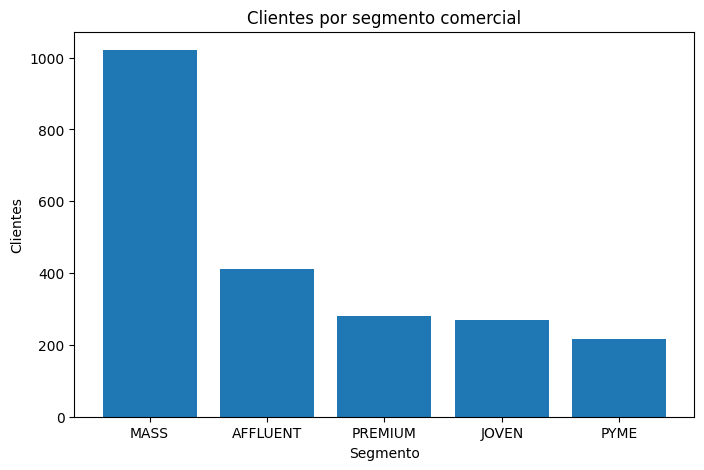

In [138]:
segmentos = clientes["segmento"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(segmentos.index, segmentos.values)
plt.xlabel("Segmento")
plt.ylabel("Clientes")
plt.title("Clientes por segmento comercial")
plt.show()

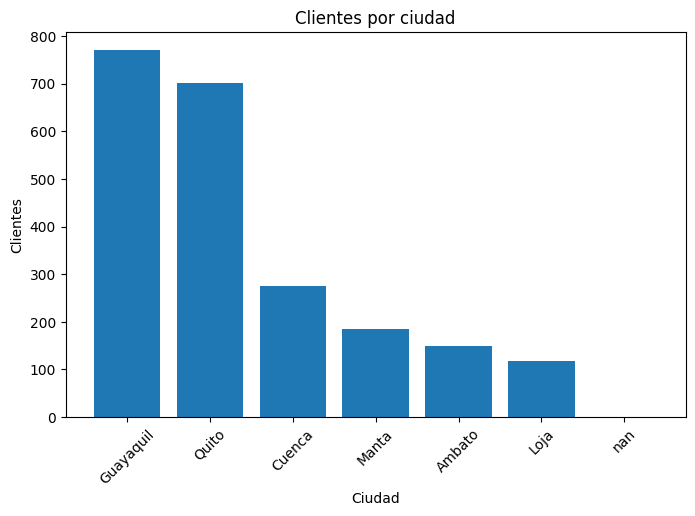

In [139]:
ciudades = clientes["ciudad"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(ciudades.index, ciudades.values)
plt.xlabel("Ciudad")
plt.ylabel("Clientes")
plt.title("Clientes por ciudad")
plt.xticks(rotation=45)
plt.show()

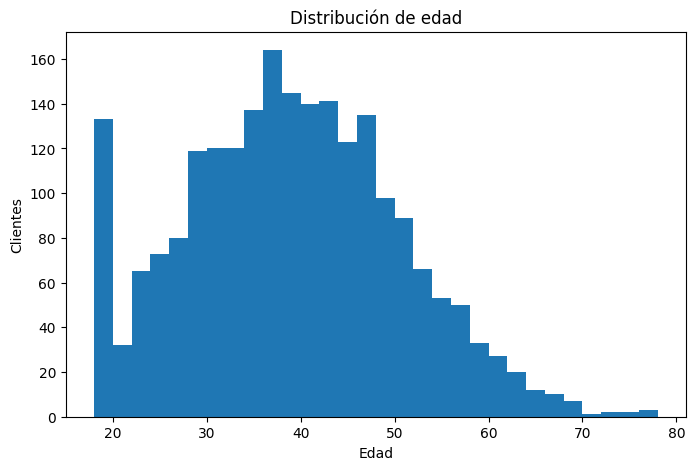

In [140]:
plt.figure(figsize=(8, 5))
plt.hist(clientes["edad"], bins=30)
plt.xlabel("Edad")
plt.ylabel("Clientes")
plt.title("Distribución de edad")
plt.show()

In [141]:
clientes["ingreso"].describe()

,ingreso
count,2200.000000
mean,1835.211227
std,1510.101083
min,350.000000
25%,793.162500
50%,1222.190000
75%,2492.947500
max,16177.540000


In [142]:
grupos = {
    "Travel Lovers": ["TRAVEL"],
    "Streaming Lovers": ["STREAMING", "ENTERTAINMENT"],
    "Food Lovers": ["FOOD", "SUPERMARKET"],
    "Tech Lovers": ["TECHNOLOGY"],
    "Wellness Lovers": ["HEALTH", "EDUCATION"]
}

grupos

{'Travel Lovers': ['TRAVEL'],
 'Streaming Lovers': ['STREAMING', 'ENTERTAINMENT'],
 'Food Lovers': ['FOOD', 'SUPERMARKET'],
 'Tech Lovers': ['TECHNOLOGY'],
 'Wellness Lovers': ['HEALTH', 'EDUCATION']}

In [143]:
# Asegurar que el monto sea numérico
df["monto_consumo"] = pd.to_numeric(
    df["monto_consumo"],
    errors="coerce"
).fillna(0)

# Consumo total del portafolio
consumo_total_portafolio = df["monto_consumo"].sum()

# Calcular peso de cada grupo
peso_portafolio = {}

for nombre, cats in grupos.items():
    monto_grupo = df.loc[
        df["categoria_consumo"].isin(cats),
        "monto_consumo"
    ].sum()

    peso_portafolio[nombre] = (
        monto_grupo / consumo_total_portafolio
        if consumo_total_portafolio > 0
        else 0
    )

# Mostrar resultados
pd.Series(peso_portafolio).sort_values(
    ascending=False
).round(3)

,0
Food Lovers,0.292
Streaming Lovers,0.208
Wellness Lovers,0.132
Travel Lovers,0.125
Tech Lovers,0.109


In [144]:
df.head(30)

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_estado,aplica_fecha_vencimiento,primer_movimiento_cliente_producto,categoria_saldo,tiene_cupo
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,0.0,NaT,2026-01-15,NO APLICA,0.00,Branch,Activo,NO APLICA,NO,2025-12-08,VALIDADO - HISTÓRICO DISPONIBLE,NO
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,0.0,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-02-02,VALIDADO - HISTÓRICO DISPONIBLE,NO
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,CON CUPO,SI,2025-01-28,VALIDADO - HISTÓRICO DISPONIBLE,SI
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,0.0,NaT,2025-06-09,NO APLICA,0.00,App,Activo,NO APLICA,NO,2025-06-09,VALIDADO - HISTÓRICO DISPONIBLE,NO
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,CON CUPO,SI,2025-01-18,VALIDADO - HISTÓRICO DISPONIBLE,SI
5,C000651,Cliente 0651,JOVEN,Cuenca,49,1023.60,Cuenta de Ahorros,4082.56,0.0,NaT,2025-07-28,NO APLICA,0.00,Web,Activo,NO APLICA,NO,2025-07-28,VALIDADO - HISTÓRICO DISPONIBLE,NO
6,C001846,Cliente 1846,MASS,Ambato,50,829.13,Tarjeta de Crédito,649.01,1200.0,2029-07-08,2026-04-10,EDUCATION,14.63,Web,Activo,CON CUPO,SI,2025-03-08,VALIDADO - HISTÓRICO DISPONIBLE,SI
7,C000851,Cliente 0851,JOVEN,Quito,24,1043.27,Tarjeta de Crédito,363.70,1100.0,2027-03-25,2025-09-01,TECHNOLOGY,48.49,POS,Activo,CON CUPO,SI,2025-04-29,VALIDADO - HISTÓRICO DISPONIBLE,SI
8,C000041,Cliente 0041,JOVEN,Quito,42,591.95,Crédito Hipotecario,63176.59,0.0,2029-06-21,2025-10-03,NO APLICA,0.00,Web,Activo,NO APLICA,SI,2025-10-03,VALIDADO - HISTÓRICO DISPONIBLE,NO
9,C000856,Cliente 0856,PREMIUM,Quito,36,4550.48,Crédito Vehicular,17442.60,0.0,2027-06-28,2025-11-21,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-11-21,VALIDADO - HISTÓRICO DISPONIBLE,NO


In [145]:
for nombre in grupos:
    umbral = max(peso_portafolio[nombre] * 1.5, 0.20)
    print(f"{nombre:<20} peso {peso_portafolio[nombre]:.1%}   ->   umbral {umbral:.1%}")

Travel Lovers        peso 12.5%   ->   umbral 20.0%
Streaming Lovers     peso 20.8%   ->   umbral 31.3%
Food Lovers          peso 29.2%   ->   umbral 43.8%
Tech Lovers          peso 10.9%   ->   umbral 20.0%
Wellness Lovers      peso 13.2%   ->   umbral 20.0%


In [146]:
import pandas as pd
import numpy as np
# Asegurar tipos
df["monto_consumo"] = pd.to_numeric(
    df["monto_consumo"],
    errors="coerce"
).fillna(0)

# Una fila por cliente y categoría
consumo = (
    df.groupby(["cliente_id", "categoria_consumo"])
      .agg(
          monto=("monto_consumo", "sum"),
          trx=("monto_consumo", "count")
      )
      .reset_index()
)

# Consumo total por cliente
totales = (
    df.groupby("cliente_id")["monto_consumo"]
      .sum()
      .rename("consumo_total")
      .reset_index()
)

# Unir total
consumo = consumo.merge(
    totales,
    on="cliente_id",
    how="left"
)

# Participación
consumo["share"] = np.where(
    consumo["consumo_total"] > 0,
    consumo["monto"] / consumo["consumo_total"],
    0
)

consumo.head()

,cliente_id,categoria_consumo,monto,trx,consumo_total,share
0,C000001,ENTERTAINMENT,449.07,1,3384.12,0.132699
1,C000001,FOOD,281.67,2,3384.12,0.083233
2,C000001,HEALTH,55.60,1,3384.12,0.016430
3,C000001,NO APLICA,0.00,1,3384.12,0.000000
4,C000001,OTHERS,217.78,1,3384.12,0.064354


In [147]:
# Crear una fila por cliente
clientes_segmentacion = (
    df[["cliente_id"]]
    .drop_duplicates()
    .copy()
)

In [148]:
MIN_TRX = 3
MIN_MONTO = 50
FACTOR = 1.5
PISO = 0.20

for nombre, cats in grupos.items():

    temp = (
        consumo[
            consumo["categoria_consumo"].isin(cats)
        ]
        .groupby("cliente_id")
        .agg(
            monto_grupo=("monto", "sum"),
            trx_grupo=("trx", "sum")
        )
        .reset_index()
    )

    temp = temp.merge(
        totales,
        on="cliente_id",
        how="left"
    )

    temp["share_grupo"] = np.where(
        temp["consumo_total"] > 0,
        temp["monto_grupo"] / temp["consumo_total"],
        0
    )

    umbral = max(
        peso_portafolio[nombre] * FACTOR,
        PISO
    )

    temp["lover"] = (
        (temp["share_grupo"] >= umbral) &
        (temp["trx_grupo"] >= MIN_TRX) &
        (temp["monto_grupo"] >= MIN_MONTO)
    ).astype(int)

    temp = temp[["cliente_id", "lover"]].rename(
        columns={"lover": "lover_" + nombre}
    )

    clientes_segmentacion = clientes_segmentacion.merge(
        temp,
        on="cliente_id",
        how="left"
    )

# Los clientes sin consumo en una categoría quedan en 0
columnas_lover = [
    "lover_" + nombre
    for nombre in grupos
]

clientes_segmentacion[columnas_lover] = (
    clientes_segmentacion[columnas_lover]
    .fillna(0)
    .astype(int)
)

In [149]:
clientes_segmentacion["n_lovers"] = (
    clientes_segmentacion[
        ["lover_" + n for n in grupos]
    ].sum(axis=1)
)

clientes_segmentacion["n_lovers"].value_counts().sort_index()

,count
n_lovers,
0,1140
1,960
2,99
3,1


In [150]:
df["segmento_cliente"]

,segmento_cliente
0,MASS
1,MASS
2,JOVEN
3,MASS
4,PREMIUM
...,...
22450,MASS
22451,MASS
22452,MASS
22453,MASS


In [151]:
# Copia de la tabla de segmentación
segmentacion = clientes_segmentacion.copy()

# Inicialmente todos son General
segmentacion["segmento_cliente"] = "General"

In [153]:
segmentacion["segmento_cliente"] = "General"

for nombre in grupos:

    mask = (
        (segmentacion["n_lovers"] == 1) &
        (segmentacion["lover_" + nombre] == 1)
    )

    segmentacion.loc[
        mask,
        "segmento_cliente"
    ] = nombre

In [154]:
segmentacion.loc[
    segmentacion["n_lovers"] > 1,
    "segmento_cliente"
] = "Diversificado"

In [155]:
segmentacion["segmento_cliente"].value_counts()

,count
segmento_cliente,
General,1140
Food Lovers,321
Streaming Lovers,245
Travel Lovers,145
Wellness Lovers,126
Tech Lovers,123
Diversificado,100


In [156]:
segmentacion.head()

,cliente_id,lover_Travel Lovers,lover_Streaming Lovers,lover_Food Lovers,lover_Tech Lovers,lover_Wellness Lovers,n_lovers,segmento_cliente
0,C000728,0,0,0,0,0,0,General
1,C001264,0,0,0,0,0,0,General
2,C001515,0,1,0,1,0,2,Diversificado
3,C002171,1,0,0,0,0,1,Travel Lovers
4,C001848,0,0,1,0,0,1,Food Lovers


In [157]:
# ============================================================
# TABLA FINAL DE SEGMENTACIÓN
# ============================================================

# Partimos de todos los clientes
segmentacion = (
    df[["cliente_id"]]
    .drop_duplicates()
    .copy()
)

# Agregar consumo total por cliente
segmentacion = segmentacion.merge(
    totales,
    on="cliente_id",
    how="left"
)

# Agregar número de Lovers
segmentacion = segmentacion.merge(
    clientes_segmentacion[
        ["cliente_id", "n_lovers"]
    ],
    on="cliente_id",
    how="left"
)

# Inicialmente todos quedan como General
segmentacion["segmento_cliente"] = "General"

In [158]:
display(segmentacion.head())

,cliente_id,consumo_total,n_lovers,segmento_cliente
0,C000728,166.19,0,General
1,C001264,392.94,0,General
2,C001515,458.31,2,General
3,C002171,517.10,1,General
4,C001848,3367.59,1,General


In [109]:
df.to_csv(
    "dataset_bancario_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

df.to_excel(
    "dataset_bancario_limpio.xlsx",
    index=False
)

In [159]:
duplicados = df.duplicated()
cantidad_duplicados = duplicados.sum()

print("Duplicados encontrados:", cantidad_duplicados)

df = df.drop_duplicates().copy()

Duplicados encontrados: 0


In [160]:
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentaje": (df.isnull().mean() * 100).round(2)
})

nulos_filtrados = (
    nulos[nulos["Nulos"] > 0]
    .sort_values("Porcentaje", ascending=False)
)

display(nulos_filtrados)

,Nulos,Porcentaje
fecha_vencimiento,3443,15.41
saldo_producto,8,0.04


In [161]:
import unicodedata

def key_cat(s):
    if pd.isna(s):
        return s

    return (
        unicodedata
        .normalize("NFKD", str(s))
        .encode("ascii", "ignore")
        .decode()
        .strip()
        .upper()
    )

In [162]:
MAPA_PRODUCTO = {
    "CUENTA DE AHORROS": "Cuenta de Ahorros",
    "CUENTA CORRIENTE": "Cuenta Corriente",
    "TARJETA DE CREDITO": "Tarjeta de Crédito",
    "CREDITO DE CONSUMO": "Crédito de Consumo",
    "CREDITO HIPOTECARIO": "Crédito Hipotecario",
    "CREDITO VEHICULAR": "Crédito Vehicular"
}

df["producto"] = df["producto"].map(
    lambda x: MAPA_PRODUCTO.get(key_cat(x), x)
)

In [163]:
print("Productos:")
display(df["producto"].value_counts())

print("Categorías de consumo:")
display(df["categoria_consumo"].value_counts())

Productos:


,count
producto,
Tarjeta de Crédito,14873
Cuenta de Ahorros,1730
Cuenta Corriente,1713
Crédito de Consumo,1433
Crédito Hipotecario,1369
Crédito Vehicular,1224


Categorías de consumo:


,count
categoria_consumo,
NO APLICA,7469
SUPERMARKET,2226
FOOD,2198
TRAVEL,1757
STREAMING,1752
TECHNOLOGY,1680
ENTERTAINMENT,1362
OTHERS,1027
HEALTH,987


In [164]:
df.head()

,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto,cupo_credito_estado,aplica_fecha_vencimiento,primer_movimiento_cliente_producto,categoria_saldo,tiene_cupo
0,C000728,Cliente 0728,MASS,Loja,50,1019.90,Cuenta de Ahorros,1498.82,0.0,NaT,2026-01-15,NO APLICA,0.00,Branch,Activo,NO APLICA,NO,2025-12-08,VALIDADO - HISTÓRICO DISPONIBLE,NO
1,C001264,Cliente 1264,MASS,Guayaquil,57,471.10,Crédito Vehicular,20725.80,0.0,2029-11-14,2026-03-20,NO APLICA,0.00,App,Activo,NO APLICA,SI,2025-02-02,VALIDADO - HISTÓRICO DISPONIBLE,NO
2,C001515,Cliente 1515,JOVEN,Manta,45,639.34,Tarjeta de Crédito,689.27,1200.0,2029-03-16,2025-11-06,FOOD,16.63,Branch,Activo,CON CUPO,SI,2025-01-28,VALIDADO - HISTÓRICO DISPONIBLE,SI
3,C002171,Cliente 2171,MASS,Guayaquil,23,1159.30,Cuenta de Ahorros,5001.88,0.0,NaT,2025-06-09,NO APLICA,0.00,App,Activo,NO APLICA,NO,2025-06-09,VALIDADO - HISTÓRICO DISPONIBLE,NO
4,C001848,Cliente 1848,PREMIUM,Guayaquil,46,3037.26,Tarjeta de Crédito,1955.00,8200.0,2028-12-28,2025-03-04,FOOD,51.91,App,Activo,CON CUPO,SI,2025-01-18,VALIDADO - HISTÓRICO DISPONIBLE,SI


In [166]:
segmentacion.head()

,cliente_id,consumo_total,n_lovers,segmento_cliente
0,C000728,166.19,0,General
1,C001264,392.94,0,General
2,C001515,458.31,2,General
3,C002171,517.10,1,General
4,C001848,3367.59,1,General


In [167]:
Q1 = df["monto_consumo"].quantile(0.25)
Q3 = df["monto_consumo"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df["monto_consumo"] < limite_inferior) |
    (df["monto_consumo"] > limite_superior)
]

print("Cantidad de posibles outliers:", len(outliers))

Cantidad de posibles outliers: 1927


In [168]:
vista_cliente = (
    df.groupby("cliente_id")
      .agg(
          nombre_cliente=("nombre_cliente", "first"),
          segmento_original=("segmento_cliente", "first"),
          ciudad=("ciudad", "first"),
          edad=("edad", "first"),
          ingreso_estimado=("ingreso_estimado", "first"),
          productos=("producto", "nunique"),
          saldo_total=("saldo_producto", "sum"),
          consumo_total=("monto_consumo", "sum"),
          transacciones=("monto_consumo", "count"),
          fecha_ultima_transaccion=("fecha_movimiento", "max"),
          fecha_primera_transaccion=("fecha_movimiento", "min")
      )
      .reset_index()
)

In [169]:
fecha_corte = df["fecha_movimiento"].max()

vista_cliente["recencia_dias"] = (
    fecha_corte -
    vista_cliente["fecha_ultima_transaccion"]
).dt.days

In [170]:
justificacion_segmentos = pd.DataFrame([
    {
        "Segmento": "Food Lovers",
        "Criterio": "Alta concentración de consumo en FOOD/SUPERMARKET + frecuencia mínima",
        "Decisión comercial": "Cashback y alianzas con supermercados para aumentar recurrencia"
    },
    {
        "Segmento": "Streaming Lovers",
        "Criterio": "Consumo recurrente en STREAMING/ENTERTAINMENT",
        "Decisión comercial": "Promover débito automático y beneficios de suscripción"
    },
    {
        "Segmento": "Travel Lovers",
        "Criterio": "Alta concentración de consumo en TRAVEL",
        "Decisión comercial": "Millas, seguros de viaje y beneficios internacionales"
    },
    {
        "Segmento": "Tech Lovers",
        "Criterio": "Concentración de consumo en TECHNOLOGY",
        "Decisión comercial": "Compras diferidas y cupo adicional en fechas comerciales"
    },
    {
        "Segmento": "Wellness Lovers",
        "Criterio": "Consumo concentrado en HEALTH/EDUCATION",
        "Decisión comercial": "Crédito educativo, salud y planes de financiamiento"
    }
])

In [172]:
justificacion_segmentos.head()

,Segmento,Criterio,Decisión comercial
0,Food Lovers,Alta concentración de consumo en FOOD/SUPERMAR...,Cashback y alianzas con supermercados para aum...
1,Streaming Lovers,Consumo recurrente en STREAMING/ENTERTAINMENT,Promover débito automático y beneficios de sus...
2,Travel Lovers,Alta concentración de consumo en TRAVEL,"Millas, seguros de viaje y beneficios internac..."
3,Tech Lovers,Concentración de consumo en TECHNOLOGY,Compras diferidas y cupo adicional en fechas c...
4,Wellness Lovers,Consumo concentrado en HEALTH/EDUCATION,"Crédito educativo, salud y planes de financiam..."


In [175]:
segmentacion.loc[
    (segmentacion["consumo_total"] == 0),
    "segmento_cliente"
] = "Solo Ahorro / Sin consumo"

In [176]:
segmentacion.head()

,cliente_id,consumo_total,n_lovers,segmento_cliente
0,C000728,166.19,0,General
1,C001264,392.94,0,General
2,C001515,458.31,2,General
3,C002171,517.10,1,General
4,C001848,3367.59,1,General


In [177]:
consumo_categoria = (
    df.groupby("categoria_consumo")["monto_consumo"]
      .agg(["sum", "count", "mean"])
      .sort_values("sum", ascending=False)
)

display(consumo_categoria)

,sum,count,mean
categoria_consumo,,,
FOOD,273898.38,2198,124.612548
SUPERMARKET,270096.54,2226,121.337170
TRAVEL,232897.48,1757,132.554058
STREAMING,213607.12,1752,121.921872
TECHNOLOGY,203106.99,1680,120.897018
ENTERTAINMENT,174461.16,1362,128.091894
OTHERS,131968.02,1027,128.498559
EDUCATION,123590.38,944,130.922013
HEALTH,121719.42,987,123.322614


In [178]:
clientes_sin_consumo = (
    vista_cliente["consumo_total"] == 0
).sum()

total_clientes = vista_cliente["cliente_id"].nunique()

porcentaje_sin_consumo = (
    clientes_sin_consumo / total_clientes * 100
)

print(porcentaje_sin_consumo)

24.772727272727273


In [179]:
vista_cliente["recencia_dias"].describe()

,recencia_dias
count,2200.000000
mean,78.976818
std,99.519039
min,0.000000
25%,18.000000
50%,44.000000
75%,98.000000
max,606.000000


In [180]:
clientes_inactivos = vista_cliente[
    vista_cliente["recencia_dias"] > 90
]

print("Clientes con más de 90 días sin consumo:",
      len(clientes_inactivos))

Clientes con más de 90 días sin consumo: 614


In [181]:
vista_cliente["ticket_promedio"] = np.where(
    vista_cliente["transacciones"] > 0,
    vista_cliente["consumo_total"] /
    vista_cliente["transacciones"],
    0
)

In [182]:
vista_cliente[
    ["consumo_total", "transacciones", "ticket_promedio"]
].describe()

,consumo_total,transacciones,ticket_promedio
count,2200.000000,2200.000000,2200.000000
mean,846.564095,10.155455,67.963548
std,1093.803704,5.145577,81.165787
min,0.000000,1.000000,0.000000
25%,91.335000,6.000000,10.447500
50%,492.445000,10.000000,43.603562
75%,1152.102500,14.000000,93.468000
max,10233.930000,24.000000,755.680000


In [205]:
criterios = pd.DataFrame([
    {
        "Segmento": "Travel Lovers",
        "Tipo": "Conductual",
        "Categorías": "TRAVEL",
        "Peso portafolio": 0.125049587,
        "Umbral participación": 0.20,
        "Mín. transacciones": 3,
        "Mín. monto": 50,
        "Criterio": "Alta concentración del consumo en Travel"
    },
    {
        "Segmento": "Streaming Lovers",
        "Tipo": "Conductual",
        "Categorías": "STREAMING + ENTERTAINMENT",
        "Peso portafolio": 0.208365408,
        "Umbral participación": 0.312548,
        "Mín. transacciones": 3,
        "Mín. monto": 50,
        "Criterio": "Alta concentración del consumo en Streaming/Entertainment"
    },
    {
        "Segmento": "Food Lovers",
        "Tipo": "Conductual",
        "Categorías": "FOOD + SUPERMARKET",
        "Peso portafolio": 0.292087061,
        "Umbral participación": 0.438131,
        "Mín. transacciones": 3,
        "Mín. monto": 50,
        "Criterio": "Alta concentración del consumo en Food/Supermarket"
    },
    {
        "Segmento": "Tech Lovers",
        "Tipo": "Conductual",
        "Categorías": "TECHNOLOGY",
        "Peso portafolio": 0.109054187,
        "Umbral participación": 0.20,
        "Mín. transacciones": 3,
        "Mín. monto": 50,
        "Criterio": "Alta concentración del consumo en Technology"
    },
    {
        "Segmento": "Wellness Lovers",
        "Tipo": "Conductual",
        "Categorías": "HEALTH + EDUCATION",
        "Peso portafolio": 0.131714131,
        "Umbral participación": 0.20,
        "Mín. transacciones": 3,
        "Mín. monto": 50,
        "Criterio": "Alta concentración del consumo en Health/Education"
    },
    {
        "Segmento": "Diversificado",
        "Tipo": "Conductual",
        "Categorías": "Varias",
        "Peso portafolio": None,
        "Umbral participación": None,
        "Mín. transacciones": None,
        "Mín. monto": None,
        "Criterio": "Consumo relevante distribuido entre varias categorías sin una dominante"
    },
    {
        "Segmento": "Transaccional básico",
        "Tipo": "Actividad",
        "Categorías": "Consumo",
        "Peso portafolio": None,
        "Umbral participación": None,
        "Mín. transacciones": None,
        "Mín. monto": None,
        "Criterio": "Baja actividad transaccional y/o alta recencia"
    },
    {
        "Segmento": "Solo Ahorro / Sin consumo",
        "Tipo": "Cartera",
        "Categorías": "NO APLICA / SIN CONSUMO",
        "Peso portafolio": None,
        "Umbral participación": None,
        "Mín. transacciones": 0,
        "Mín. monto": 0,
        "Criterio": "Mantiene relación y/o saldo pero no registra consumo categorizable"
    },
    {
        "Segmento": "Producto reciente / Sin histórico",
        "Tipo": "Cartera",
        "Categorías": "NO APLICA",
        "Peso portafolio": None,
        "Umbral participación": None,
        "Mín. transacciones": None,
        "Mín. monto": None,
        "Criterio": "Producto nuevo sin suficiente histórico para evaluar comportamiento"
    }
])
criterios.head()

,Segmento,Tipo,Categorías,Peso portafolio,Umbral participación,Mín. transacciones,Mín. monto,Criterio
0,Travel Lovers,Conductual,TRAVEL,0.125050,0.200000,3.0,50.0,Alta concentración del consumo en Travel
1,Streaming Lovers,Conductual,STREAMING + ENTERTAINMENT,0.208365,0.312548,3.0,50.0,Alta concentración del consumo en Streaming/En...
2,Food Lovers,Conductual,FOOD + SUPERMARKET,0.292087,0.438131,3.0,50.0,Alta concentración del consumo en Food/Superma...
3,Tech Lovers,Conductual,TECHNOLOGY,0.109054,0.200000,3.0,50.0,Alta concentración del consumo en Technology
4,Wellness Lovers,Conductual,HEALTH + EDUCATION,0.131714,0.200000,3.0,50.0,Alta concentración del consumo en Health/Educa...


In [188]:
consumo_cliente_categoria = (
    df.groupby(
        ["cliente_id", "categoria_consumo"],
        as_index=False
    )["monto_consumo"]
    .sum()
)

consumo_cliente_categoria.head()

,cliente_id,categoria_consumo,monto_consumo
0,C000001,ENTERTAINMENT,449.07
1,C000001,FOOD,281.67
2,C000001,HEALTH,55.60
3,C000001,NO APLICA,0.00
4,C000001,OTHERS,217.78


In [189]:
consumo_lovers = []

for segmento, categorias in grupos.items():

    temp = (
        consumo_cliente_categoria[
            consumo_cliente_categoria["categoria_consumo"].isin(categorias)
        ]
        .groupby("cliente_id", as_index=False)["monto_consumo"]
        .sum()
        .rename(columns={
            "monto_consumo": segmento
        })
    )

    consumo_lovers.append(temp)

In [190]:
from functools import reduce

consumo_lovers = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="cliente_id",
        how="outer"
    ),
    consumo_lovers
)

consumo_lovers = consumo_lovers.fillna(0)

consumo_lovers.head()

,cliente_id,Travel Lovers,Streaming Lovers,Food Lovers,Tech Lovers,Wellness Lovers
0,C000001,0.00,1206.82,672.42,1231.50,55.60
1,C000002,0.00,27.66,41.73,0.00,0.00
2,C000003,147.89,306.26,456.69,0.00,0.00
3,C000006,56.68,0.00,48.30,73.84,29.73
4,C000007,521.41,0.00,255.47,0.00,67.76


In [191]:
columnas_lovers = list(grupos.keys())

consumo_lovers["mayor_consumo"] = (
    consumo_lovers[columnas_lovers]
    .idxmax(axis=1)
)

In [192]:
consumo_lovers["consumo_total"] = (
    consumo_lovers[columnas_lovers].sum(axis=1)
)

In [193]:
consumo_lovers["monto_mayor_categoria"] = (
    consumo_lovers[columnas_lovers].max(axis=1)
)

consumo_lovers["share_mayor_categoria"] = (
    consumo_lovers["monto_mayor_categoria"]
    / consumo_lovers["consumo_total"]
).fillna(0)

In [194]:
UMBRAL_SHARE = 0.20
MIN_TRX = 3
MIN_MONTO = 50

In [195]:
trx_cliente_categoria = (
    df.groupby(
        ["cliente_id", "categoria_consumo"]
    )
    .size()
    .reset_index(name="trx")
)

In [196]:
segmentacion_final = consumo_lovers[
    [
        "cliente_id",
        "consumo_total",
        "mayor_consumo",
        "share_mayor_categoria"
    ]
].copy()

segmentacion_final = segmentacion_final.rename(
    columns={
        "mayor_consumo": "segmento_cliente"
    }
)

In [206]:
# ============================================================
# COMPLETAR SEGMENTACIÓN FINAL
# Mantiene los Lovers ya calculados
# ============================================================

# 1. Información general por cliente
info_cliente = (
    df.groupby("cliente_id")
      .agg(
          productos=("producto", "nunique"),
          saldo_total=("saldo_producto", "sum"),
          transacciones=("monto_consumo", lambda x: (x > 0).sum()),
          fecha_ultima_transaccion=("fecha_movimiento", "max")
      )
      .reset_index()
)

# Fecha de corte
fecha_corte = df["fecha_movimiento"].max()

info_cliente["recencia_dias"] = (
    fecha_corte - info_cliente["fecha_ultima_transaccion"]
).dt.days


# 2. Productos que tiene cada cliente
productos_cliente = (
    df.groupby("cliente_id")["producto"]
      .apply(set)
      .reset_index()
)

info_cliente = info_cliente.merge(
    productos_cliente,
    on="cliente_id",
    how="left"
)

info_cliente["tiene_ahorro"] = info_cliente["producto"].apply(
    lambda x: "SI" if "Cuenta de Ahorros" in x else "NO"
)

info_cliente["tiene_corriente"] = info_cliente["producto"].apply(
    lambda x: "SI" if "Cuenta Corriente" in x else "NO"
)

info_cliente["tiene_tarjeta"] = info_cliente["producto"].apply(
    lambda x: "SI" if "Tarjeta de Crédito" in x else "NO"
)


# 3. Producto nuevo / sin histórico
producto_nuevo = (
    df.groupby("cliente_id")
      .agg(
          producto_reciente=(
              "categoria_saldo",
              lambda x: (
                  x.astype(str)
                   .str.contains(
                       "SIN HISTÓRICO - PRODUCTO NUEVO",
                       case=False,
                       na=False
                   )
              ).any()
          )
      )
      .reset_index()
)

info_cliente = info_cliente.merge(
    producto_nuevo,
    on="cliente_id",
    how="left"
)

info_cliente["producto_reciente"] = np.where(
    info_cliente["producto_reciente"],
    "SI",
    "NO"
)


# 4. Unimos la información a la segmentación que YA existe
segmentacion_final = segmentacion_final.merge(
    info_cliente.drop(columns=["producto"]),
    on="cliente_id",
    how="left"
)

In [207]:
segmentacion_final.head(30)

,cliente_id,consumo_total,segmento_cliente,share_mayor_categoria,productos,saldo_total,transacciones,fecha_ultima_transaccion,recencia_dias,tiene_ahorro,tiene_corriente,tiene_tarjeta,producto_reciente
0,C000001,3166.34,Tech Lovers,0.388935,2,39838.74,10,2026-04-16,137,NO,NO,SI,NO
1,C000002,69.39,Food Lovers,0.601383,2,221386.40,5,2026-08-22,9,NO,NO,SI,NO
2,C000003,910.84,Food Lovers,0.501394,1,14949.83,7,2026-07-17,45,NO,NO,SI,NO
3,C000006,208.55,Tech Lovers,0.354064,3,34387.58,4,2025-11-20,284,NO,NO,SI,NO
4,C000007,844.64,Travel Lovers,0.617316,1,12801.60,8,2026-06-26,66,NO,NO,SI,NO
5,C000008,2552.67,Food Lovers,0.491728,4,151593.53,12,2026-07-22,40,NO,SI,SI,NO
6,C000009,204.12,Streaming Lovers,0.649912,4,13745.00,8,2026-07-27,35,SI,SI,SI,NO
7,C000010,560.37,Wellness Lovers,0.532291,2,13002.84,14,2026-08-16,15,NO,NO,SI,NO
8,C000012,299.66,Streaming Lovers,0.406194,2,138989.21,7,2026-08-26,5,NO,NO,SI,NO
9,C000013,225.89,Streaming Lovers,0.451680,3,158895.65,5,2026-08-27,4,NO,SI,SI,NO


In [208]:
# ============================================================
# CLIENTES CON CONSUMO PERO SIN LOVER
# ============================================================

sin_segmento = (
    segmentacion_final["segmento_cliente"].isna() |
    (segmentacion_final["segmento_cliente"] == "General")
)

# Clientes con varias categorías de consumo
# pero sin una clasificación Lover
segmentacion_final.loc[
    sin_segmento &
    (segmentacion_final["consumo_total"] > 0) &
    (segmentacion_final["transacciones"] >= 3),
    "segmento_cliente"
] = "Diversificado"

# Los que tienen consumo pero muy poca actividad
segmentacion_final.loc[
    segmentacion_final["segmento_cliente"].isna() &
    (segmentacion_final["consumo_total"] > 0),
    "segmento_cliente"
] = "Transaccional básico"

In [209]:
segmentacion_final[
    [
        "cliente_id",
        "consumo_total",
        "segmento_cliente",
        "share_mayor_categoria",
        "productos",
        "saldo_total",
        "transacciones",
        "recencia_dias",
        "tiene_ahorro",
        "tiene_corriente",
        "tiene_tarjeta",
        "producto_reciente"
    ]
].head(30)

,cliente_id,consumo_total,segmento_cliente,share_mayor_categoria,productos,saldo_total,transacciones,recencia_dias,tiene_ahorro,tiene_corriente,tiene_tarjeta,producto_reciente
0,C000001,3166.34,Tech Lovers,0.388935,2,39838.74,10,137,NO,NO,SI,NO
1,C000002,69.39,Food Lovers,0.601383,2,221386.40,5,9,NO,NO,SI,NO
2,C000003,910.84,Food Lovers,0.501394,1,14949.83,7,45,NO,NO,SI,NO
3,C000006,208.55,Tech Lovers,0.354064,3,34387.58,4,284,NO,NO,SI,NO
4,C000007,844.64,Travel Lovers,0.617316,1,12801.60,8,66,NO,NO,SI,NO
5,C000008,2552.67,Food Lovers,0.491728,4,151593.53,12,40,NO,SI,SI,NO
6,C000009,204.12,Streaming Lovers,0.649912,4,13745.00,8,35,SI,SI,SI,NO
7,C000010,560.37,Wellness Lovers,0.532291,2,13002.84,14,15,NO,NO,SI,NO
8,C000012,299.66,Streaming Lovers,0.406194,2,138989.21,7,5,NO,NO,SI,NO
9,C000013,225.89,Streaming Lovers,0.451680,3,158895.65,5,4,NO,SI,SI,NO


In [210]:
segmentacion_final["segmento_cliente"].value_counts()

,count
segmento_cliente,
Food Lovers,642
Streaming Lovers,403
Travel Lovers,213
Wellness Lovers,205
Tech Lovers,192


In [212]:
print("Clientes totales:", df["cliente_id"].nunique())
print("Clientes en segmentacion_final:", segmentacion_final["cliente_id"].nunique())

Clientes totales: 2200
Clientes en segmentacion_final: 1655


In [213]:
clientes_faltantes = df[
    ~df["cliente_id"].isin(segmentacion_final["cliente_id"])
].copy()

print("Clientes sin segmentar:", clientes_faltantes["cliente_id"].nunique())

Clientes sin segmentar: 545


In [214]:
revision_faltantes = (
    clientes_faltantes
    .groupby("cliente_id")
    .agg(
        consumo_total=("monto_consumo", "sum"),
        transacciones=("monto_consumo", lambda x: (x > 0).sum()),
        productos=("producto", "nunique"),
        saldo_total=("saldo_producto", "sum"),
        productos_tipo=("producto", lambda x: " | ".join(sorted(x.dropna().unique()))),
        categorias_consumo=("categoria_consumo", lambda x: " | ".join(sorted(x.dropna().unique())))
    )
    .reset_index()
)

revision_faltantes.head(30)

,cliente_id,consumo_total,transacciones,productos,saldo_total,productos_tipo,categorias_consumo
0,C000004,0.0,0,1,9049.17,Cuenta de Ahorros,NO APLICA
1,C000005,0.0,0,2,28997.68,Crédito de Consumo | Cuenta de Ahorros,NO APLICA
2,C000011,0.0,0,1,16657.64,Cuenta Corriente,NO APLICA
3,C000022,0.0,0,2,16324.01,Crédito de Consumo | Cuenta de Ahorros,NO APLICA
4,C000023,0.0,0,3,240953.62,Crédito Hipotecario | Crédito Vehicular | Cuen...,NO APLICA
5,C000032,0.0,0,1,23967.69,Crédito Vehicular,NO APLICA
6,C000033,0.0,0,3,41144.89,Crédito de Consumo | Cuenta Corriente | Cuenta...,NO APLICA
7,C000034,0.0,0,1,73582.20,Cuenta Corriente,NO APLICA
8,C000037,0.0,0,2,69516.14,Crédito Vehicular | Crédito de Consumo,NO APLICA
9,C000039,0.0,0,1,10153.92,Cuenta Corriente,NO APLICA


In [215]:
revision_producto = (
    clientes_faltantes
    .groupby("cliente_id")
    .agg(
        producto_reciente=(
            "categoria_saldo",
            lambda x: x.astype(str).str.contains(
                "SIN HISTÓRICO - PRODUCTO NUEVO",
                case=False,
                na=False
            ).any()
        ),
        sin_historico=(
            "categoria_saldo",
            lambda x: x.astype(str).str.contains(
                "SIN HISTÓRICO",
                case=False,
                na=False
            ).any()
        )
    )
    .reset_index()
)

revision_faltantes = revision_faltantes.merge(
    revision_producto,
    on="cliente_id",
    how="left"
)

revision_faltantes.head(30)

,cliente_id,consumo_total,transacciones,productos,saldo_total,productos_tipo,categorias_consumo,producto_reciente,sin_historico
0,C000004,0.0,0,1,9049.17,Cuenta de Ahorros,NO APLICA,False,False
1,C000005,0.0,0,2,28997.68,Crédito de Consumo | Cuenta de Ahorros,NO APLICA,False,False
2,C000011,0.0,0,1,16657.64,Cuenta Corriente,NO APLICA,False,False
3,C000022,0.0,0,2,16324.01,Crédito de Consumo | Cuenta de Ahorros,NO APLICA,False,False
4,C000023,0.0,0,3,240953.62,Crédito Hipotecario | Crédito Vehicular | Cuen...,NO APLICA,False,False
5,C000032,0.0,0,1,23967.69,Crédito Vehicular,NO APLICA,False,False
6,C000033,0.0,0,3,41144.89,Crédito de Consumo | Cuenta Corriente | Cuenta...,NO APLICA,False,False
7,C000034,0.0,0,1,73582.20,Cuenta Corriente,NO APLICA,False,False
8,C000037,0.0,0,2,69516.14,Crédito Vehicular | Crédito de Consumo,NO APLICA,False,False
9,C000039,0.0,0,1,10153.92,Cuenta Corriente,NO APLICA,False,False


In [216]:
faltantes = revision_faltantes.copy()

In [211]:
segmentacion.head()

,cliente_id,consumo_total,n_lovers,segmento_cliente
0,C000728,166.19,0,General
1,C001264,392.94,0,General
2,C001515,458.31,2,General
3,C002171,517.10,1,General
4,C001848,3367.59,1,General


In [217]:
faltantes["segmento_cliente"] = np.nan

# Producto nuevo / sin histórico
faltantes.loc[
    (faltantes["consumo_total"] <= 0) &
    (faltantes["producto_reciente"] == True),
    "segmento_cliente"
] = "Producto reciente"

/tmp/ipykernel_1356/3546083070.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Producto reciente' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  faltantes.loc[


In [218]:
faltantes.loc[
    (faltantes["segmento_cliente"].isna()) &
    (faltantes["consumo_total"] <= 0) &
    (faltantes["productos_tipo"].str.contains(
        "Cuenta de Ahorros",
        case=False,
        na=False
    )),
    "segmento_cliente"
] = "Solo Ahorro / Sin consumo"

In [219]:
faltantes.loc[
    (faltantes["segmento_cliente"].isna()) &
    (faltantes["consumo_total"] <= 0),
    "segmento_cliente"
] = "Solo Ahorro / Sin consumo"

In [221]:
faltantes_con_consumo = faltantes[
    (faltantes["consumo_total"] > 0)
].copy()

print(
    "Clientes con consumo que no son Lover:",
    faltantes_con_consumo["cliente_id"].nunique()
)

Clientes con consumo que no son Lover: 0


In [222]:
faltantes_con_consumo[
    [
        "cliente_id",
        "consumo_total",
        "transacciones",
        "productos_tipo",
        "categorias_consumo"
    ]
].sort_values(
    "consumo_total",
    ascending=False
).head(30)

,cliente_id,consumo_total,transacciones,productos_tipo,categorias_consumo


In [225]:
# ============================================================
# UNIR SEGMENTACIÓN FINAL + INFORMACIÓN DE NO APLICA
# ============================================================

segmentacion = segmentacion.drop(
    columns=["segmento_cliente"],
    errors="ignore"
)

segmentacion = segmentacion.merge(
    segmentacion_final[
        [
            "cliente_id",
            "consumo_total",
            "segmento_cliente",
            "share_mayor_categoria"
        ]
    ],
    on="cliente_id",
    how="left"
)

In [226]:
info_no_aplica = (
    df.groupby("cliente_id")
      .agg(
          tiene_no_aplica=(
              "categoria_consumo",
              lambda x: (x == "NO APLICA").any()
          ),
          tiene_consumo_aplicable=(
              "categoria_consumo",
              lambda x: (x != "NO APLICA").any()
          )
      )
      .reset_index()
)

segmentacion = segmentacion.merge(
    info_no_aplica,
    on="cliente_id",
    how="left"
)

In [227]:
segmentacion["tipo_consumo"] = np.select(
    [
        segmentacion["tiene_consumo_aplicable"] == True,
        segmentacion["tiene_no_aplica"] == True
    ],
    [
        "Consumo aplicable",
        "NO APLICA"
    ],
    default="Sin información"
)

In [228]:
segmentacion.head(30)

,cliente_id,consumo_total_x,n_lovers,consumo_total_y,segmento_cliente,share_mayor_categoria,tiene_no_aplica,tiene_consumo_aplicable,tipo_consumo
0,C000728,166.19,0,48.43,Travel Lovers,0.819946,True,True,Consumo aplicable
1,C001264,392.94,0,392.94,Food Lovers,0.361251,True,True,Consumo aplicable
2,C001515,458.31,2,458.31,Streaming Lovers,0.407584,True,True,Consumo aplicable
3,C002171,517.10,1,517.10,Travel Lovers,0.612473,True,True,Consumo aplicable
4,C001848,3367.59,1,3367.59,Food Lovers,0.713142,True,True,Consumo aplicable
5,C000651,617.58,1,573.10,Streaming Lovers,0.591624,True,True,Consumo aplicable
6,C001846,324.85,1,202.17,Wellness Lovers,0.537963,True,True,Consumo aplicable
7,C000851,687.03,1,687.03,Travel Lovers,0.353769,True,True,Consumo aplicable
8,C000041,450.36,0,324.44,Wellness Lovers,0.560473,True,True,Consumo aplicable
9,C000856,1528.07,0,523.20,Food Lovers,0.615577,True,True,Consumo aplicable


In [ ]:
# 1. CSV de la base limpia
df.to_csv("dataset_bancario_limpio.csv",
    index=False,
    encoding="utf-8-sig")
print("📄 dataset_bancario_limpio.csv")

In [ ]:
from google.colab import files

files.download("dataset_bancario_limpio.csv")

In [229]:
with pd.ExcelWriter(
    "dataset_bancario_final.xlsx",
    engine="openpyxl"
) as writer:

    # Base transaccional limpia
    df.to_excel(
        writer,
        sheet_name="Base_Limpia",
        index=False
    )

    # Vista analítica: 1 fila por cliente
    vista_cliente.to_excel(
        writer,
        sheet_name="Vista_Cliente",
        index=False
    )

    # Segmentación final: 1 fila por cliente
    segmentacion_final.to_excel(
        writer,
        sheet_name="Segmentacion_final",
        index=False
    )
        # Segmentación: 1 fila por cliente
    segmentacion.to_excel(
        writer,
        sheet_name="Segmentacion_cliente",
        index=False
    )

    # Justificación de cada segmento
    justificacion_segmentos.to_excel(
        writer,
        sheet_name="Justificacion",
        index=False
    )

    # Consumo de cliente por segmento
    consumo_lovers.to_excel(
        writer,
        sheet_name="Consumo",
        index=False
    )

    # Parámetros técnicos utilizados
    criterios.to_excel(
        writer,
        sheet_name="Criterios",
        index=False
    )
print("📊 dataset_bancario_final.xlsx")

📊 dataset_bancario_final.xlsx


In [230]:
from google.colab import files

files.download("dataset_bancario_final.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>